In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


| المكتبة               | الوظيفة                         |
| --------------------- | ------------------------------- |
| `pandas`              | التعامل مع الجداول والبيانات    |
| `numpy`               | العمليات الرياضية والمصفوفات    |
| `matplotlib`          | رسم المخططات                    |
| `seaborn`             | رسم مخططات إحصائية بشكل أسهل    |
| `scipy.stats`         | الاختبارات والتحليلات الإحصائية |
| `LabelEncoder`        | تحويل القيم النصية إلى أرقام    |
| `mutual_info_classif` | قياس العلاقة بين الخصائص والهدف |
|    warnings            | لمنع التحذيرات |


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = "/content/drive/MyDrive/train.csv"
#"/content/drive/MyDrive/train.csv"
data = pd.read_csv(file_path)
print("Data loaded successfully.")
print(f"Rows    : {data.shape[0]:,}")
print(f"Columns : {data.shape[1]}")

Data loaded successfully.
Rows    : 691,369
Columns : 14


In [4]:
display(data.head())

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [5]:
display(data.tail())

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1
691368,691368,21.0,5.64,1.03,3.05,1.01,4.91,169.0,NaN,9.47,Other,Medium,Yes,0


In [6]:
print("\nColumn Names:")
print(data.columns.tolist())


Column Names:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'addicted_label']


| العمود                    | المعنى                                                      |
| ------------------------- | ----------------------------------------------------------- |
| `id`                      | رقم تعريفي لكل سجل/شخص                                      |
| `age`                     | عمر الشخص                                                   |
| `daily_screen_time_hours` | عدد ساعات استخدام الشاشة يوميًا                             |
| `social_media_hours`      | عدد الساعات اليومية على وسائل التواصل الاجتماعي             |
| `gaming_hours`            | عدد الساعات اليومية في الألعاب                              |
| `work_study_hours`        | عدد الساعات اليومية للعمل أو الدراسة                        |
| `sleep_hours`             | عدد ساعات النوم                                             |
| `notifications_per_day`   | عدد الإشعارات التي يستقبلها الشخص يوميًا                    |
| `app_opens_per_day`       | عدد مرات فتح التطبيقات يوميًا                               |
| `weekend_screen_time`     | وقت استخدام الشاشة في عطلة نهاية الأسبوع                    |
| `gender`                  | جنس الشخص                                                   |
| `stress_level`            | مستوى التوتر                                                |
| `academic_work_impact`    | تأثير استخدام الهاتف/الشاشة على العمل أو الدراسة الأكاديمية |
| `addicted_label`          | **الهدف الذي نريد التنبؤ به**: هل الشخص مصنف كمُدمن أم لا   |


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [8]:
dtype_table = pd.DataFrame({
    "Column": data.columns,
    "Data_Type": data.dtypes.astype(str),
    "Unique_Values": data.nunique().values,
    "Missing_Count": data.isna().sum().values,
    "Missing_Percent": (data.isna().mean() * 100).round(2).values
})
dtype_table.loc["Total"] = [
    "Total",
    "-",
    "-",
    data.isna().sum().sum(),
    data.isna().mean().mean() * 100
]
display(dtype_table)

,Column,Data_Type,Unique_Values,Missing_Count,Missing_Percent
id,id,int64,691369,0,0.000000
age,age,float64,18,28929,4.180000
daily_screen_time_hours,daily_screen_time_hours,float64,1389,95854,13.860000
social_media_hours,social_media_hours,float64,721,133995,19.380000
gaming_hours,gaming_hours,float64,401,126821,18.340000
work_study_hours,work_study_hours,float64,600,51518,7.450000
sleep_hours,sleep_hours,float64,451,44480,6.430000
notifications_per_day,notifications_per_day,float64,231,67584,9.780000
app_opens_per_day,app_opens_per_day,float64,166,80710,11.670000
weekend_screen_time,weekend_screen_time,float64,1437,112063,16.210000


هذا الجدول مهم جدًا لأنه يعطينا:

نوع العمود
عدد القيم المختلفة
عدد Missing
نسبة Missing

In [9]:
missing = pd.DataFrame({
    "Missing_Count": data.isna().sum(),
    "Missing_Percentage": data.isna().mean() * 100
})
missing = missing.sort_values(
    "Missing_Percentage",
    ascending=False
)
display(missing)

,Missing_Count,Missing_Percentage
social_media_hours,133995,19.381112
gaming_hours,126821,18.343461
weekend_screen_time,112063,16.208855
daily_screen_time_hours,95854,13.864376
app_opens_per_day,80710,11.673940
notifications_per_day,67584,9.775388
stress_level,55148,7.976638
work_study_hours,51518,7.451592
sleep_hours,44480,6.433612
academic_work_impact,44224,6.396584


# رسم توضيحي يبين عدد القيم المفقوده في كل عمود

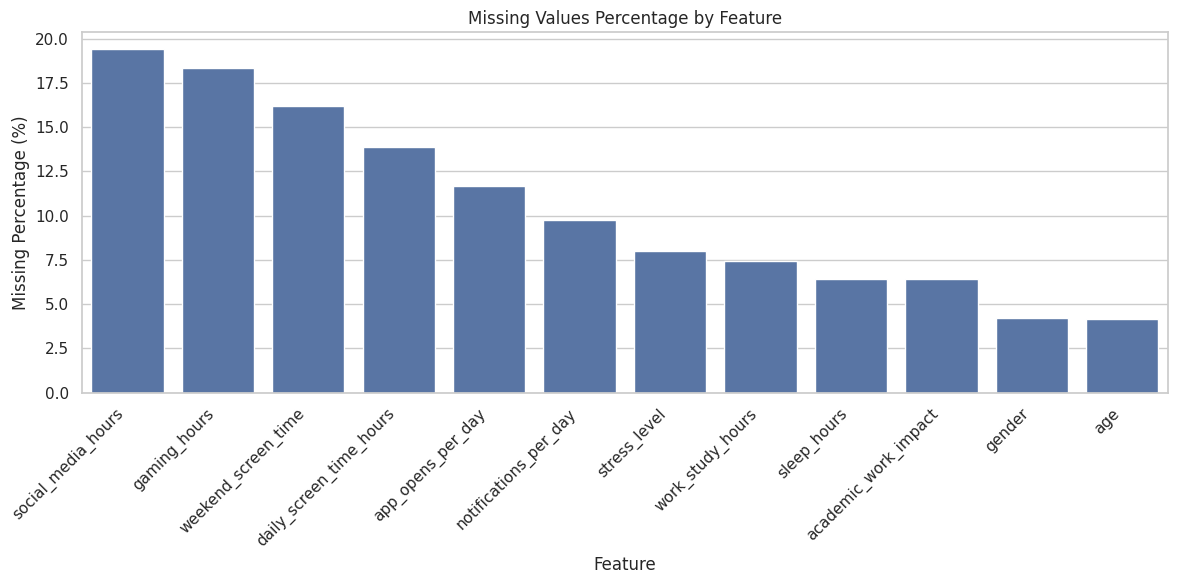

In [10]:
missing_plot = missing[missing["Missing_Count"] > 0]
plt.figure(figsize=(12, 6))
sns.barplot(
    x=missing_plot.index,
    y=missing_plot["Missing_Percentage"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Feature")
plt.title("Missing Values Percentage by Feature")
plt.tight_layout()
plt.show()

# معرفه القيم المتكرره

In [11]:
duplicate_count = data.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")
print(
    f"Duplicate percentage: "
    f"{duplicate_count / len(data) * 100:.4f}%"
)

Duplicate rows: 0
Duplicate percentage: 0.0000%


# فصل الاعمدة الرقميه هن الاعمدة الفئوية

In [12]:
target = "addicted_label"
numeric_features = data.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = data.select_dtypes(
    include=["object", "category"]
).columns.tolist()


if target in numeric_features:
    numeric_features.remove(target)

if "id" in numeric_features:
    numeric_features.remove("id")

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

Categorical Features:
['gender', 'stress_level', 'academic_work_impact']


# الإحصاءات الوصفية المتقدمة

In [13]:
desc = data[numeric_features].describe().T
desc["missing"] = data[numeric_features].isna().sum()
desc["missing_%"] = (
    data[numeric_features].isna().mean() * 100
)
desc["skewness"] = data[numeric_features].skew()
display(desc)

,count,mean,std,min,25%,50%,75%,max,missing,missing_%,skewness
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00,28929,4.184307,-0.036801
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00,95854,13.864376,-0.131972
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00,133995,19.381112,0.468081
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00,126821,18.343461,0.544740
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00,51518,7.451592,0.563457
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00,44480,6.433612,-0.006587
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00,67584,9.775388,-0.206535
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00,80710,11.673940,-0.126463
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56,112063,16.208855,-0.063408


| المتغير                     | المتوسط | الوسيط | Skewness | نسبة القيم المفقودة | الاستنتاج                                                                         |
| --------------------------- | ------: | -----: | -------: | ------------------: | --------------------------------------------------------------------------------- |
| **age**                     |   26.62 |  27.00 |   -0.037 |               4.18% | المتوسط قريب جدًا من الوسيط، والتوزيع شبه متماثل.                                 |
| **daily_screen_time_hours** |    7.64 |   7.77 |   -0.132 |              13.86% | توزيع قريب من التماثل مع انحراف سالب بسيط.                                        |
| **social_media_hours**      |    2.47 |   2.31 |   +0.468 |          **19.38%** | المتوسط أكبر من الوسيط، مما يتوافق مع انحراف موجب بسيط. وله أعلى نسبة قيم مفقودة. |
| **gaming_hours**            |    1.46 |   1.33 |   +0.545 |          **18.34%** | المتوسط أكبر من الوسيط، ويوجد انحراف موجب واضح نسبيًا.                            |
| **work_study_hours**        |    2.37 |   2.20 |   +0.563 |               7.45% | أعلى قيمة Skewness موجبة، مما يشير إلى ميل التوزيع نحو اليمين.                    |
| **sleep_hours**             |    6.80 |   6.80 |   -0.007 |               6.43% | المتوسط والوسيط متساويان تقريبًا، والتوزيع شبه متماثل جدًا.                       |
| **notifications_per_day**   |  145.89 | 150.00 |   -0.207 |               9.78% | الوسيط أكبر من المتوسط، ويتوافق ذلك مع انحراف سالب بسيط.                          |
| **app_opens_per_day**       |  102.64 | 104.00 |   -0.126 |              11.67% | الوسيط أكبر قليلًا من المتوسط، والانحراف السالب ضعيف.                             |
| **weekend_screen_time**     |    9.48 |   9.58 |   -0.063 |              16.21% | التوزيع قريب جدًا من التماثل، مع انحراف سالب ضعيف.                                |


In [14]:
# توزيع المتغيرات الرقمية

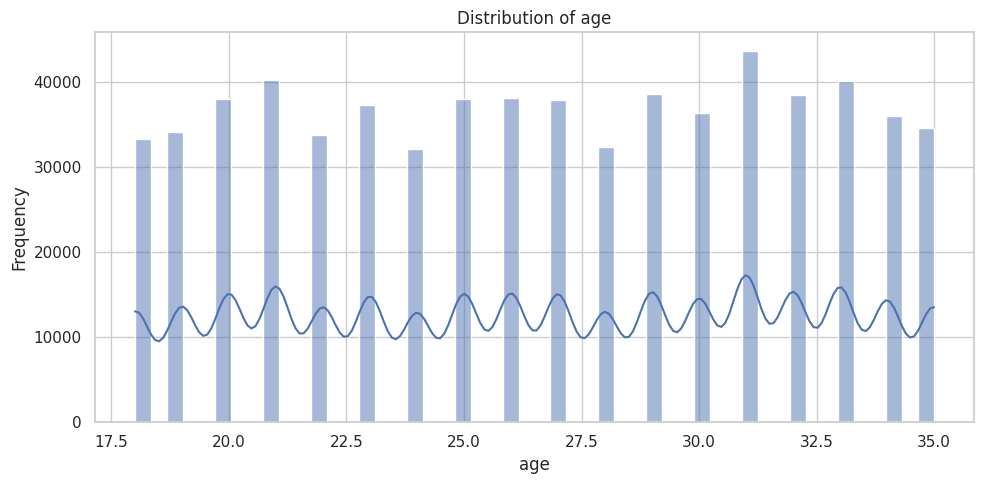

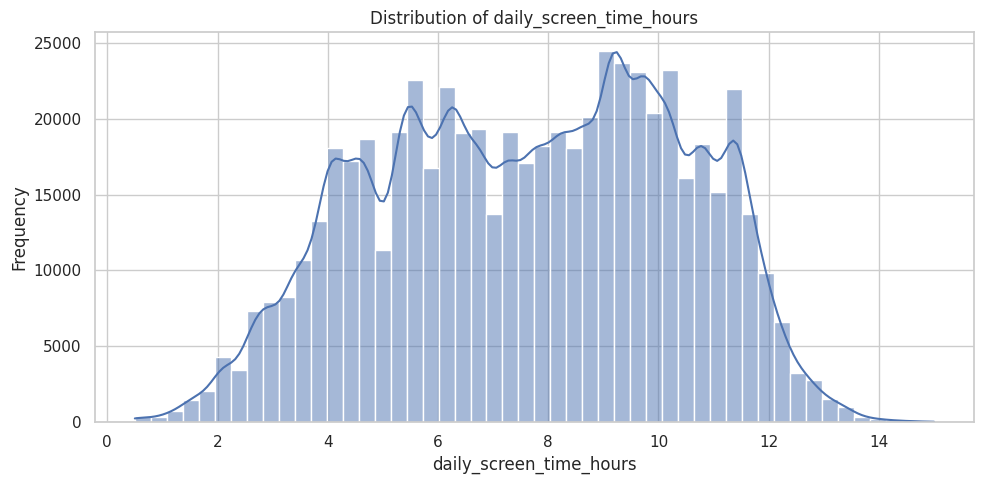

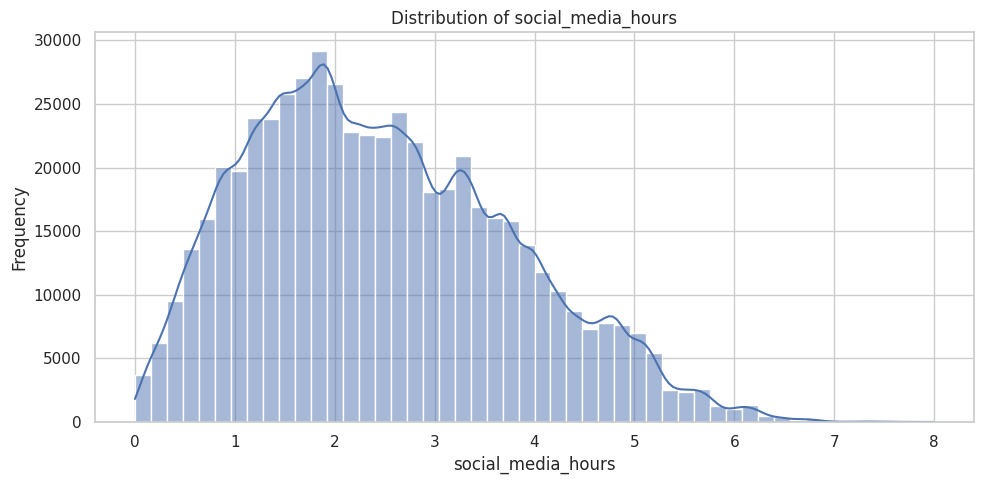

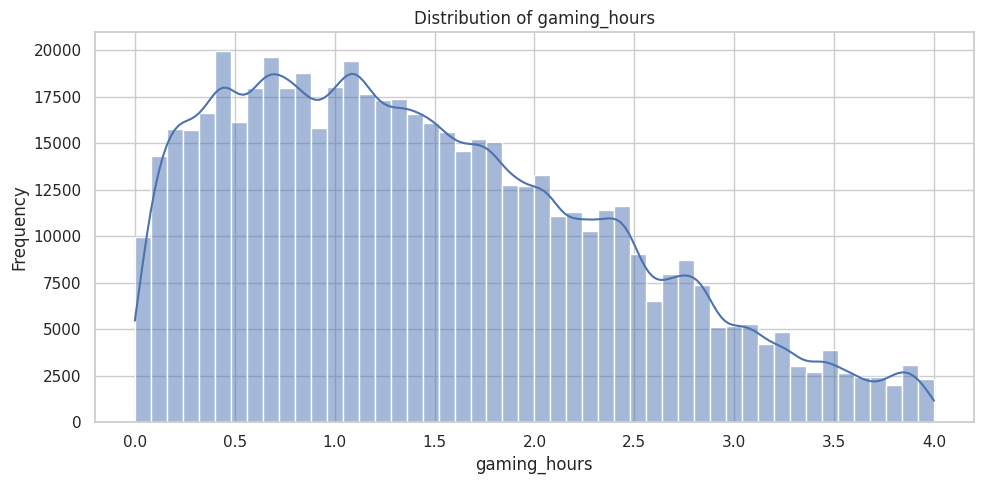

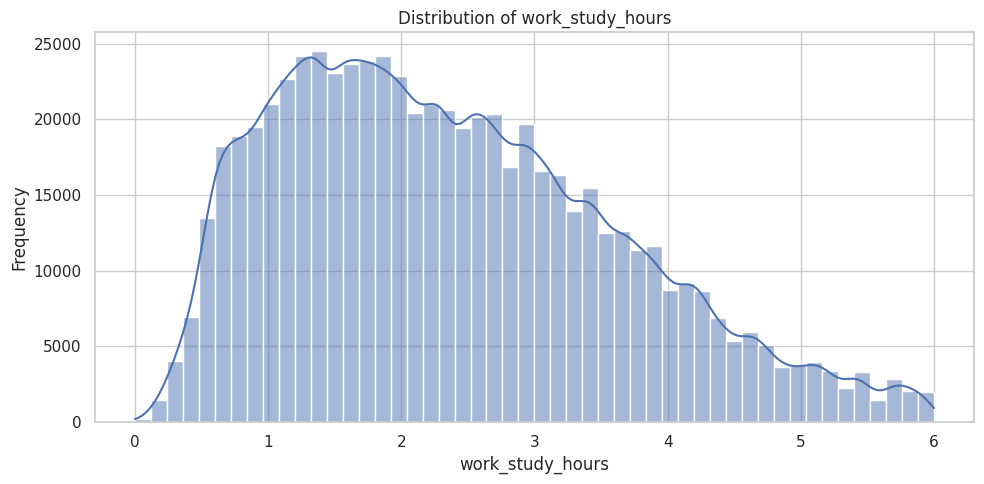

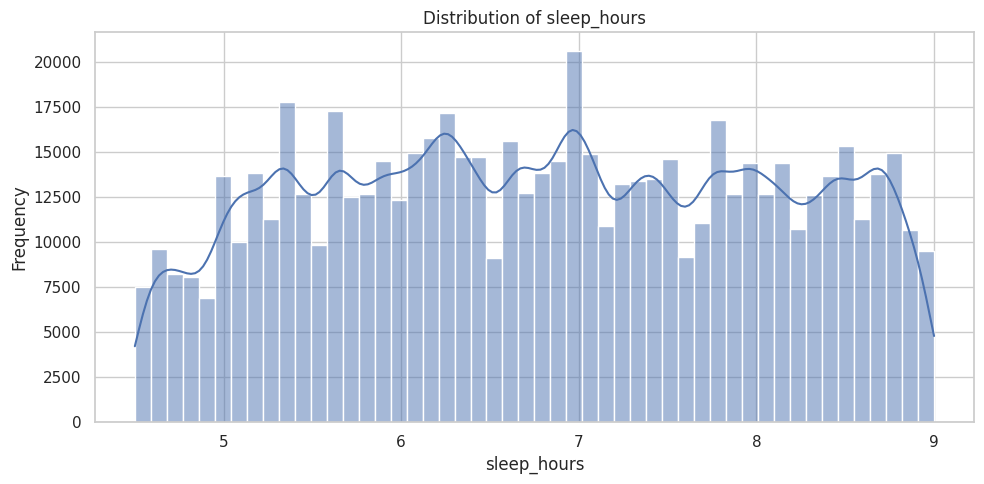

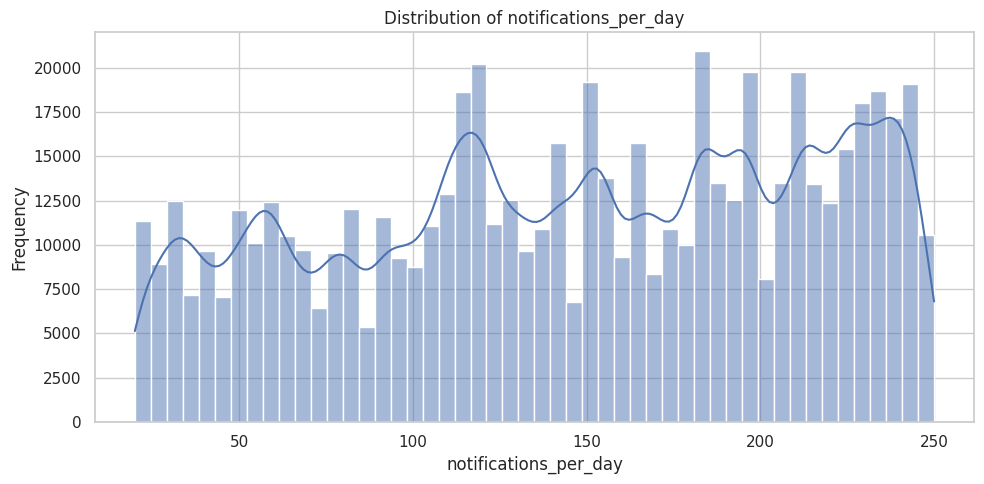

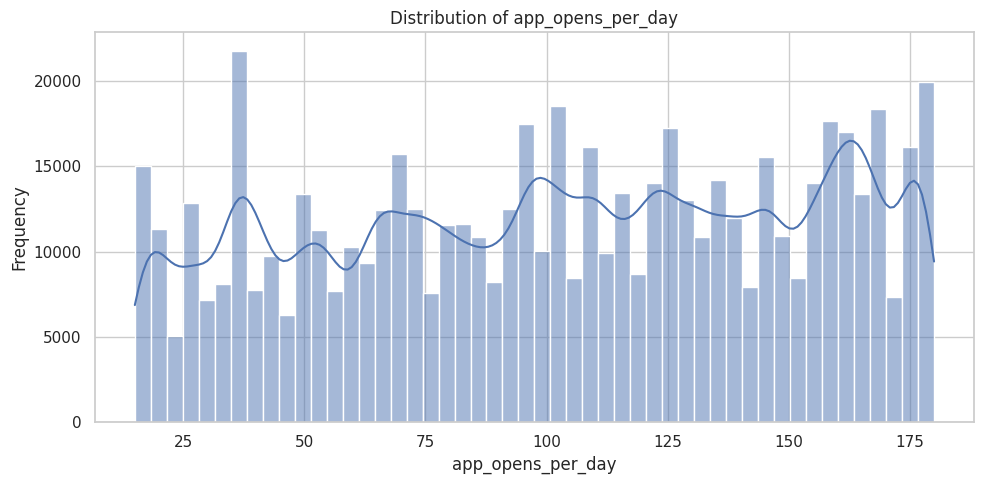

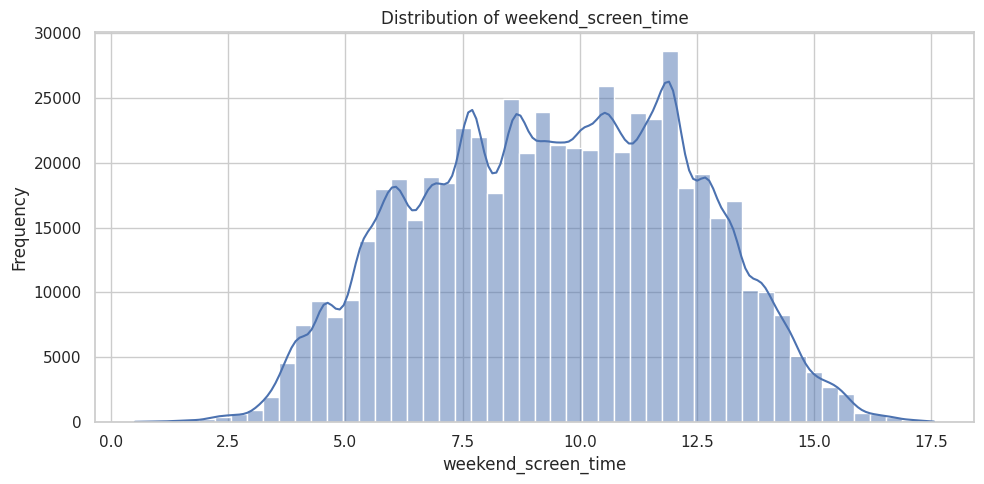

In [15]:
for col in numeric_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(
        data[col],
        bins=50,
        kde=True
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

هذا سيكشف لنا مثلًا:

هل age موزع بشكل طبيعي؟
هل daily_screen_time_hours منحرف؟
هل notifications_per_day يحتوي على ذيل طويل؟
هل app_opens_per_day يحتوي على قيم مرتفعة جدًا؟

# معرفه القيم المتطرفه

In [16]:
outlier_summary = []
for col in numeric_features:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = (
        (data[col] < lower) |
        (data[col] > upper)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outliers": outliers,
        "Outlier_%": outliers / len(data) * 100
    })
outlier_df = pd.DataFrame(outlier_summary)

display(
    outlier_df.sort_values(
        "Outlier_%",
        ascending=False
    )
)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outliers,Outlier_%
2,social_media_hours,1.45,3.37,1.92,-1.430,6.250,1209,0.174870
4,work_study_hours,1.36,3.20,1.84,-1.400,5.960,300,0.043392
8,weekend_screen_time,7.28,11.75,4.47,0.575,18.455,6,0.000868
0,age,22.00,31.00,9.00,8.500,44.500,0,0.000000
1,daily_screen_time_hours,5.48,9.84,4.36,-1.060,16.380,0,0.000000
3,gaming_hours,0.70,2.09,1.39,-1.385,4.175,0,0.000000
5,sleep_hours,5.78,7.87,2.09,2.645,11.005,0,0.000000
6,notifications_per_day,93.00,204.00,111.00,-73.500,370.500,0,0.000000
7,app_opens_per_day,64.00,145.00,81.00,-57.500,266.500,0,0.000000


#الاستنتاجات
| الاستنتاج                                 | النتيجة                                                                 |
| ----------------------------------------- | ----------------------------------------------------------------------- |
| **عدد المتغيرات التي تحتوي على Outliers** | 3 متغيرات فقط من أصل 9                                                  |
| **عدد المتغيرات بدون Outliers**           | 6 متغيرات                                                               |
| **أكثر متغير يحتوي على Outliers**         | `social_media_hours` بعدد **1209**                                      |
| **نسبة Outliers في `social_media_hours`** | **0.175%** فقط                                                          |
| **ثاني أعلى متغير**                       | `work_study_hours` بعدد **300** وبنسبة **0.043%**                       |
| **أقل عدد من Outliers**                   | `weekend_screen_time` بعدد **6** وبنسبة **0.001%**                      |
| **بقية المتغيرات**                        | لا توجد فيها قيم متطرفة حسب معيار IQR                                   |
| **حجم المشكلة**                           | القيم المتطرفة قليلة جدًا مقارنة بحجم البيانات                          |
| **قرار المعالجة**                         | لا يُنصح بحذفها مباشرة؛ يجب أولًا التحقق من كونها أخطاء أم قيمًا حقيقية |


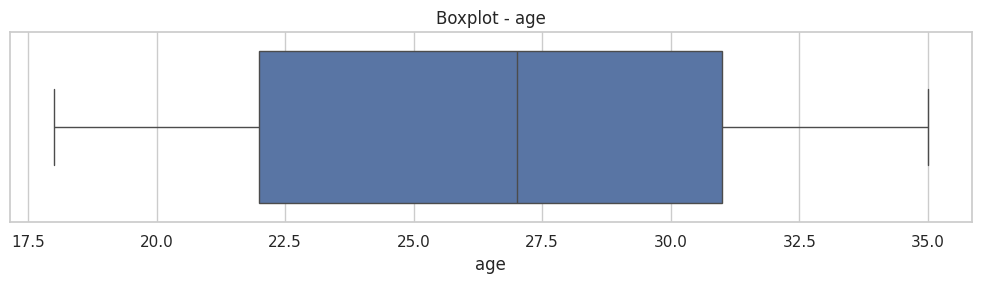

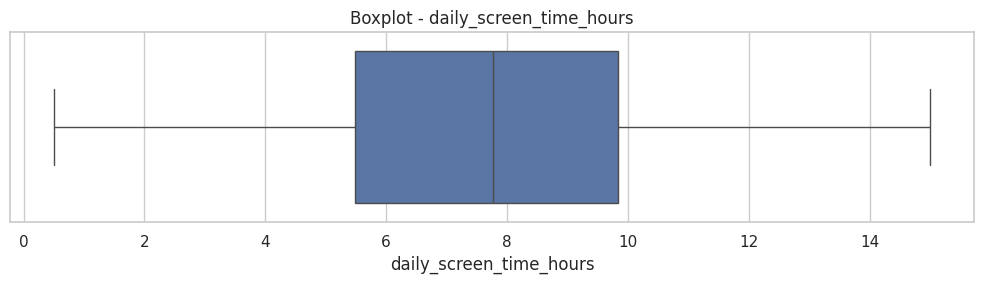

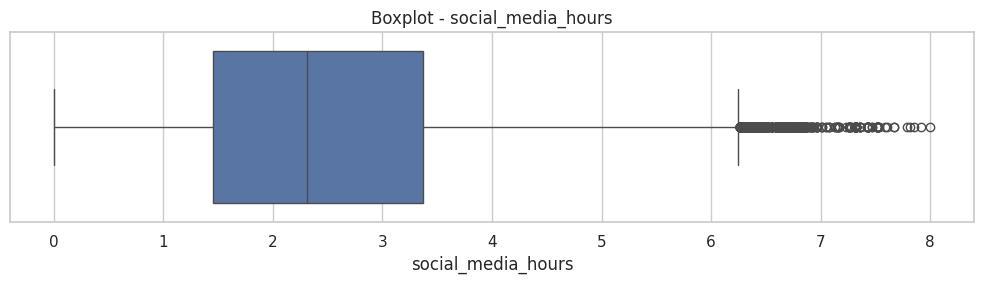

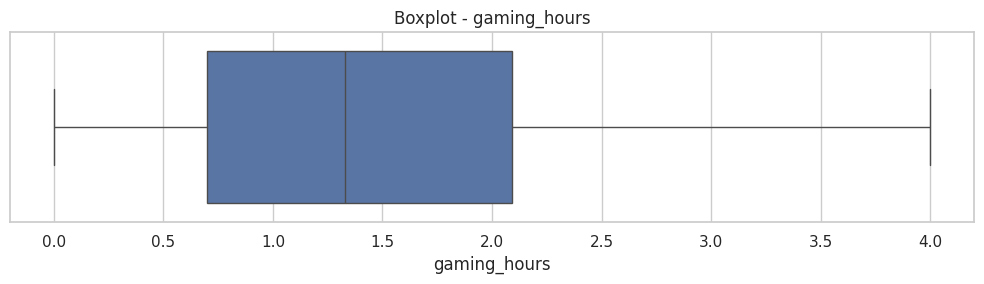

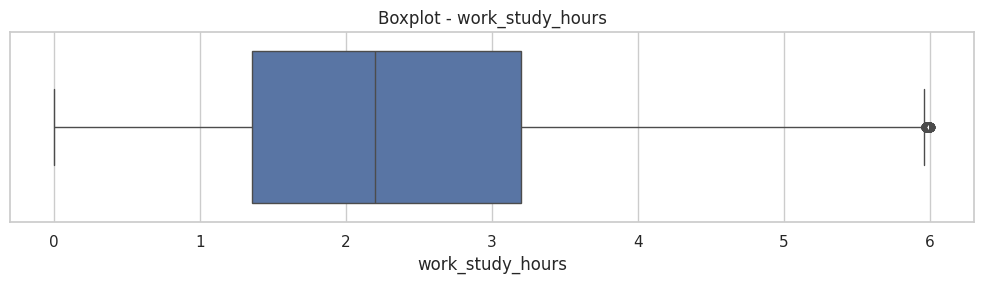

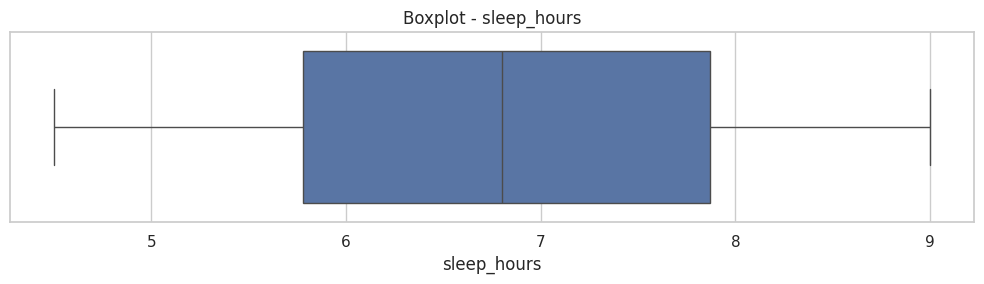

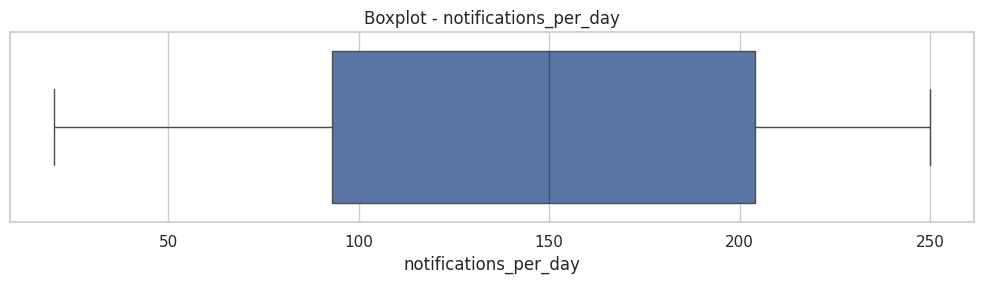

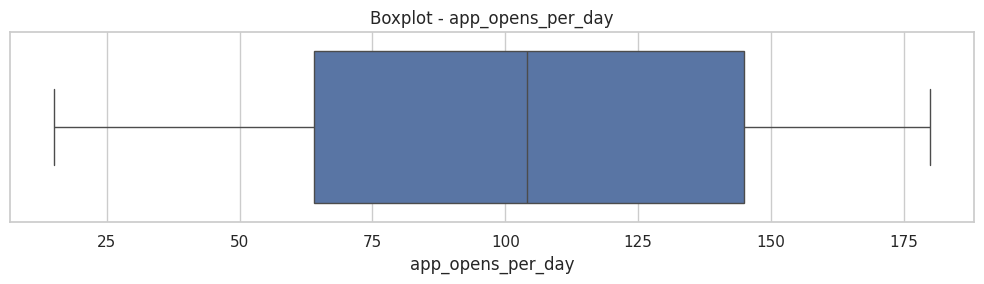

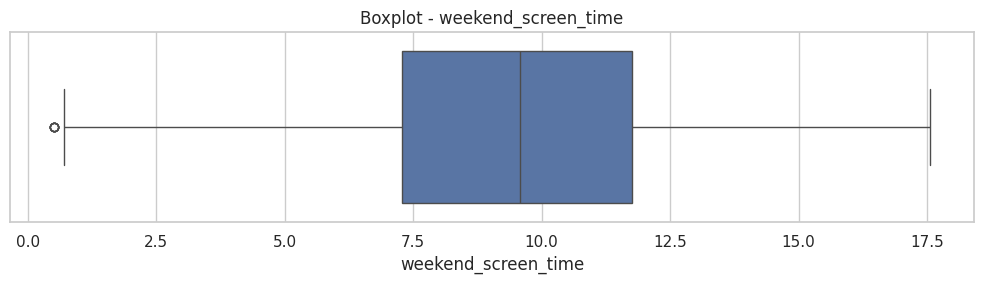

In [17]:
for col in numeric_features:
    plt.figure(figsize=(10, 3))
    sns.boxplot(
        x=data[col]
    )
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# تحليل المتغيرات الفئوية

In [18]:

for col in categorical_features:
    print("=" * 70)
    print(f"Feature: {col}")
    print("=" * 70)
    print(data[col].value_counts(dropna=False))
    print("\nPercentages:")
    print(
        data[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

#data[categorical_features].describe().T

Feature: gender
gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64

Percentages:
gender
Male      32.35
Female    32.05
Other     31.40
NaN        4.20
Name: proportion, dtype: float64
Feature: stress_level
stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64

Percentages:
stress_level
High      31.95
Low       30.05
Medium    30.02
NaN        7.98
Name: proportion, dtype: float64
Feature: academic_work_impact
academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64

Percentages:
academic_work_impact
Yes    47.81
No     45.79
NaN     6.40
Name: proportion, dtype: float64


# عرض المتغيرات الفئويه

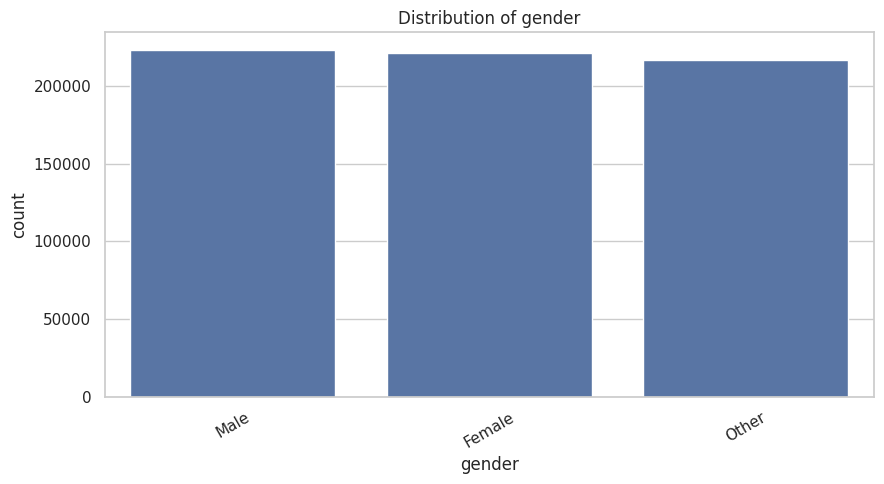

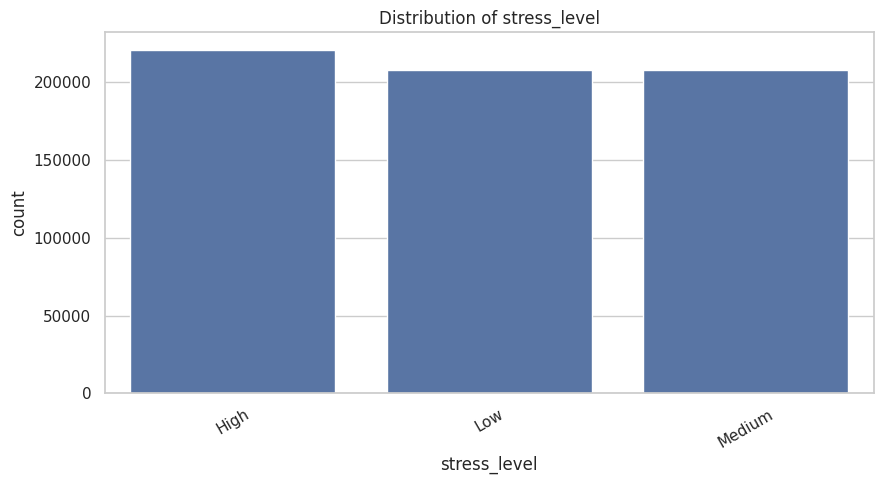

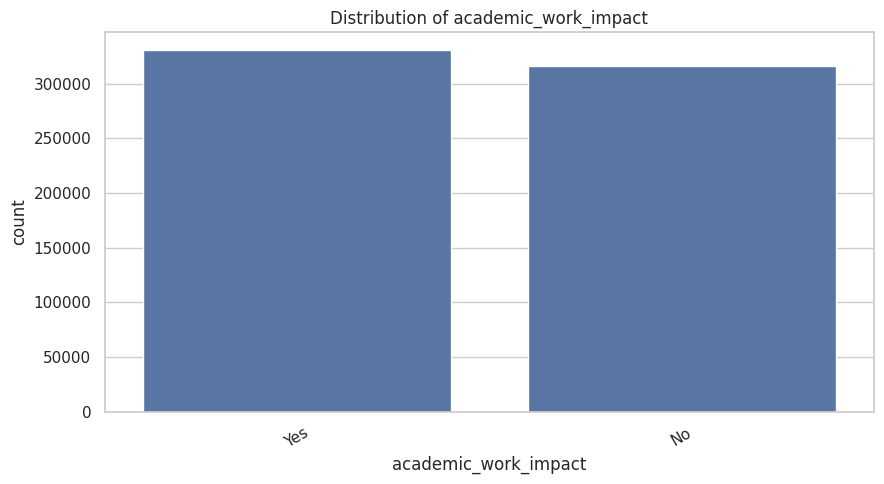

In [19]:
for col in categorical_features:
    plt.figure(figsize=(9, 5))
    order = data[col].value_counts().index
    sns.countplot(
        data=data,
        x=col,
        order=order
    )
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

 #  تحليل الهدف addicted_label

In [20]:
target_counts = data[target].value_counts()
print(target_counts)
print("\nPercentages:")
print(
    data[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# يوجد تحيز في البيانات

addicted_label
1    490474
0    200895
Name: count, dtype: int64

Percentages:
addicted_label
1    70.94
0    29.06
Name: proportion, dtype: float64


# عرض المتغير الهدف

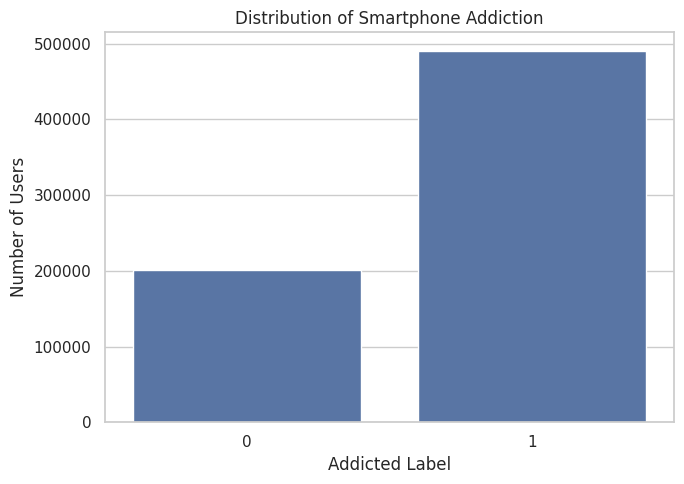

In [21]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=data,
    x=target
)
plt.title("Distribution of Smartphone Addiction")
plt.xlabel("Addicted Label")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

# متوسط كل متغير حسب حالة الإدمان

In [22]:
group_means = (
    data
    .groupby(target)[numeric_features]
    .mean()
    .T
)
display(group_means)

addicted_label,0,1
age,26.582864,26.628749
daily_screen_time_hours,5.042929,8.706523
social_media_hours,1.376144,2.919495
gaming_hours,1.159677,1.582119
work_study_hours,1.872582,2.569566
sleep_hours,6.722321,6.837970
notifications_per_day,147.087661,145.406142
app_opens_per_day,97.871440,104.592844
weekend_screen_time,6.848920,10.558729


| المتغير                              | غير المدمنين (0) | المدمنين (1) | الاستنتاج الواضح                                                      |
| ------------------------------------ | ---------------: | -----------: | --------------------------------------------------------------------- |
| **العمر**                            |            26.58 |        26.63 | لا يوجد فرق يُذكر في العمر بين المجموعتين.                            |
| **وقت الشاشة اليومي**                |        5.04 ساعة |    8.71 ساعة | المدمنون يستخدمون الشاشة يوميًا بمدة أكبر بكثير.                      |
| **استخدام وسائل التواصل**            |        1.38 ساعة |    2.92 ساعة | المدمنون يقضون وقتًا أكبر بكثير على وسائل التواصل الاجتماعي.          |
| **الألعاب**                          |        1.16 ساعة |    1.58 ساعة | المدمنون يقضون وقتًا أطول في الألعاب.                                 |
| **العمل/الدراسة**                    |        1.87 ساعة |    2.57 ساعة | متوسط وقت العمل/الدراسة أعلى لدى المدمنين.                            |
| **النوم**                            |        6.72 ساعة |    6.84 ساعة | ساعات النوم متقاربة جدًا بين المجموعتين.                              |
| **الإشعارات اليومية**                |           147.09 |       145.41 | لا يوجد فرق واضح في عدد الإشعارات.                                    |
| **فتح التطبيقات يوميًا**             |            97.87 |       104.59 | المدمنون يفتحون التطبيقات بمعدل أعلى.                                 |
| **وقت الشاشة في عطلة نهاية الأسبوع** |        6.85 ساعة |   10.56 ساعة | المدمنون يقضون وقتًا أطول بشكل واضح على الهاتف في عطلة نهاية الأسبوع. |


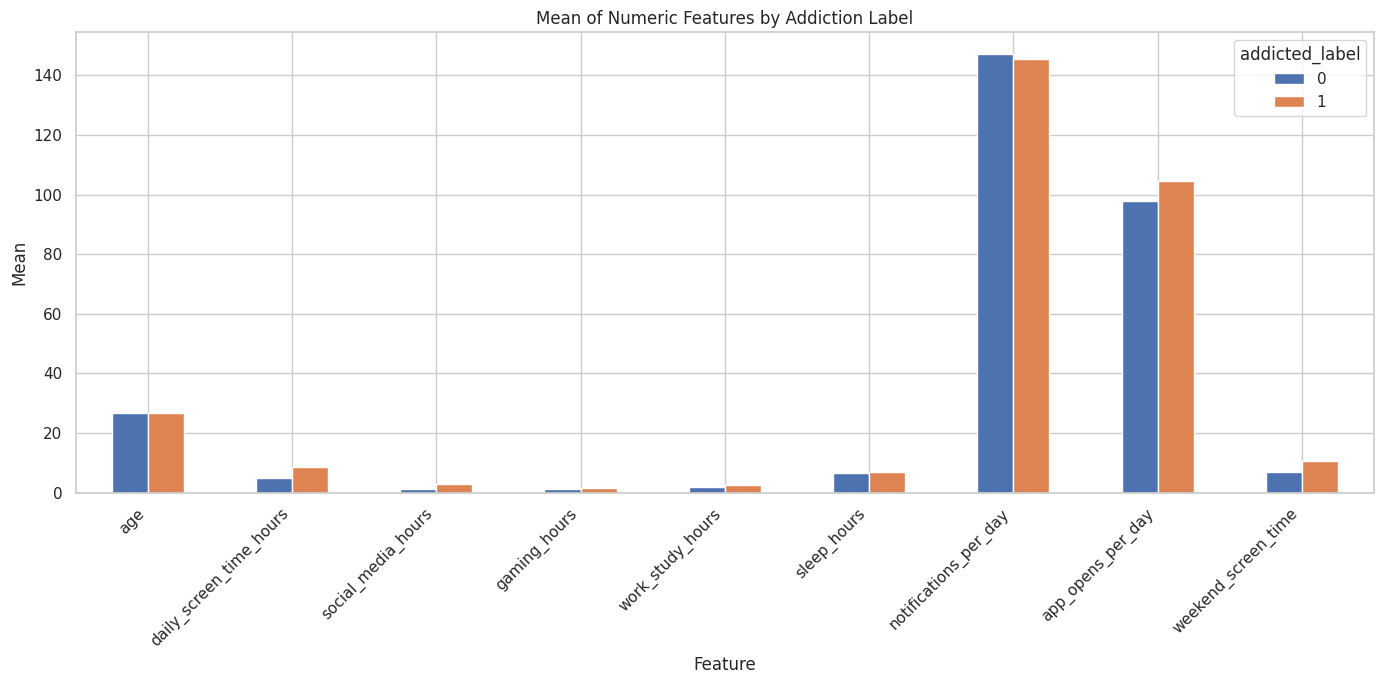

In [23]:
group_means.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Mean of Numeric Features by Addiction Label")
plt.xlabel("Feature")
plt.ylabel("Mean")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# قياس مقدار الاختلاف بين المدمنين وغير المدمنين

In [24]:
means_0 = data[data[target] == 0][numeric_features].mean()
means_1 = data[data[target] == 1][numeric_features].mean()
difference = pd.DataFrame({
    "Mean_Label_0": means_0,
    "Mean_Label_1": means_1
})
difference["Absolute_Difference"] = (
    difference["Mean_Label_1"] -
    difference["Mean_Label_0"]
)
difference["Percentage_Difference"] = (
    difference["Absolute_Difference"] /
    difference["Mean_Label_0"].replace(0, np.nan)
) * 100
difference = difference.sort_values(
    "Absolute_Difference",
    ascending=False
)
display(difference)

,Mean_Label_0,Mean_Label_1,Absolute_Difference,Percentage_Difference
app_opens_per_day,97.871440,104.592844,6.721405,6.867586
weekend_screen_time,6.848920,10.558729,3.709809,54.166346
daily_screen_time_hours,5.042929,8.706523,3.663594,72.648140
social_media_hours,1.376144,2.919495,1.543351,112.150424
work_study_hours,1.872582,2.569566,0.696984,37.220489
gaming_hours,1.159677,1.582119,0.422442,36.427572
sleep_hours,6.722321,6.837970,0.115649,1.720370
age,26.582864,26.628749,0.045885,0.172611
notifications_per_day,147.087661,145.406142,-1.681519,-1.143209


| المتغير                     | الفرق النسبي | الاستنتاج                                                                    |
| --------------------------- | -----------: | ---------------------------------------------------------------------------- |
| **social_media_hours**      | **+112.15%** | أكبر فرق نسبي؛ متوسط استخدام وسائل التواصل أعلى لدى المدمنين بأكثر من الضعف. |
| **daily_screen_time_hours** |  **+72.65%** | وقت الشاشة اليومي أعلى بشكل واضح لدى المدمنين.                               |
| **weekend_screen_time**     |  **+54.17%** | وقت استخدام الشاشة في عطلة نهاية الأسبوع أعلى بشكل واضح لدى المدمنين.        |
| **work_study_hours**        |  **+37.22%** | متوسط وقت العمل/الدراسة أعلى لدى المدمنين.                                   |
| **gaming_hours**            |  **+36.43%** | متوسط ساعات الألعاب أعلى لدى المدمنين.                                       |
| **app_opens_per_day**       |   **+6.87%** | عدد مرات فتح التطبيقات أعلى قليلًا لدى المدمنين.                             |
| **sleep_hours**             |   **+1.72%** | الفرق بسيط جدًا بين المجموعتين.                                              |
| **age**                     |   **+0.17%** | لا يوجد فرق عملي يُذكر في العمر.                                             |
| **notifications_per_day**   |   **−1.14%** | متوسط الإشعارات أقل قليلًا لدى المدمنين، والفرق صغير جدًا.                   |


In [25]:
means_0 = data[data[target] == 0][numeric_features].median()
means_1 = data[data[target] == 1][numeric_features].median()
difference = pd.DataFrame({
    "Mean_Label_0": means_0,
    "Mean_Label_1": means_1
})
difference["Absolute_Difference"] = (
    difference["Mean_Label_1"] -
    difference["Mean_Label_0"]
)
difference["Percentage_Difference"] = (
    difference["Absolute_Difference"] /
    difference["Mean_Label_0"].replace(0, np.nan)
) * 100
difference = difference.sort_values(
    "Absolute_Difference",
    ascending=False
)
display(difference)

,Mean_Label_0,Mean_Label_1,Absolute_Difference,Percentage_Difference
app_opens_per_day,99.00,109.00,10.00,10.101010
daily_screen_time_hours,5.04,9.07,4.03,79.960317
weekend_screen_time,6.82,10.79,3.97,58.211144
social_media_hours,1.29,2.82,1.53,118.604651
work_study_hours,1.75,2.47,0.72,41.142857
gaming_hours,1.07,1.48,0.41,38.317757
sleep_hours,6.72,6.84,0.12,1.785714
age,27.00,27.00,0.00,0.000000
notifications_per_day,154.00,150.00,-4.00,-2.597403


# تحليل علاقه الارتباط بين المتغيرات الرقميه و الهدف

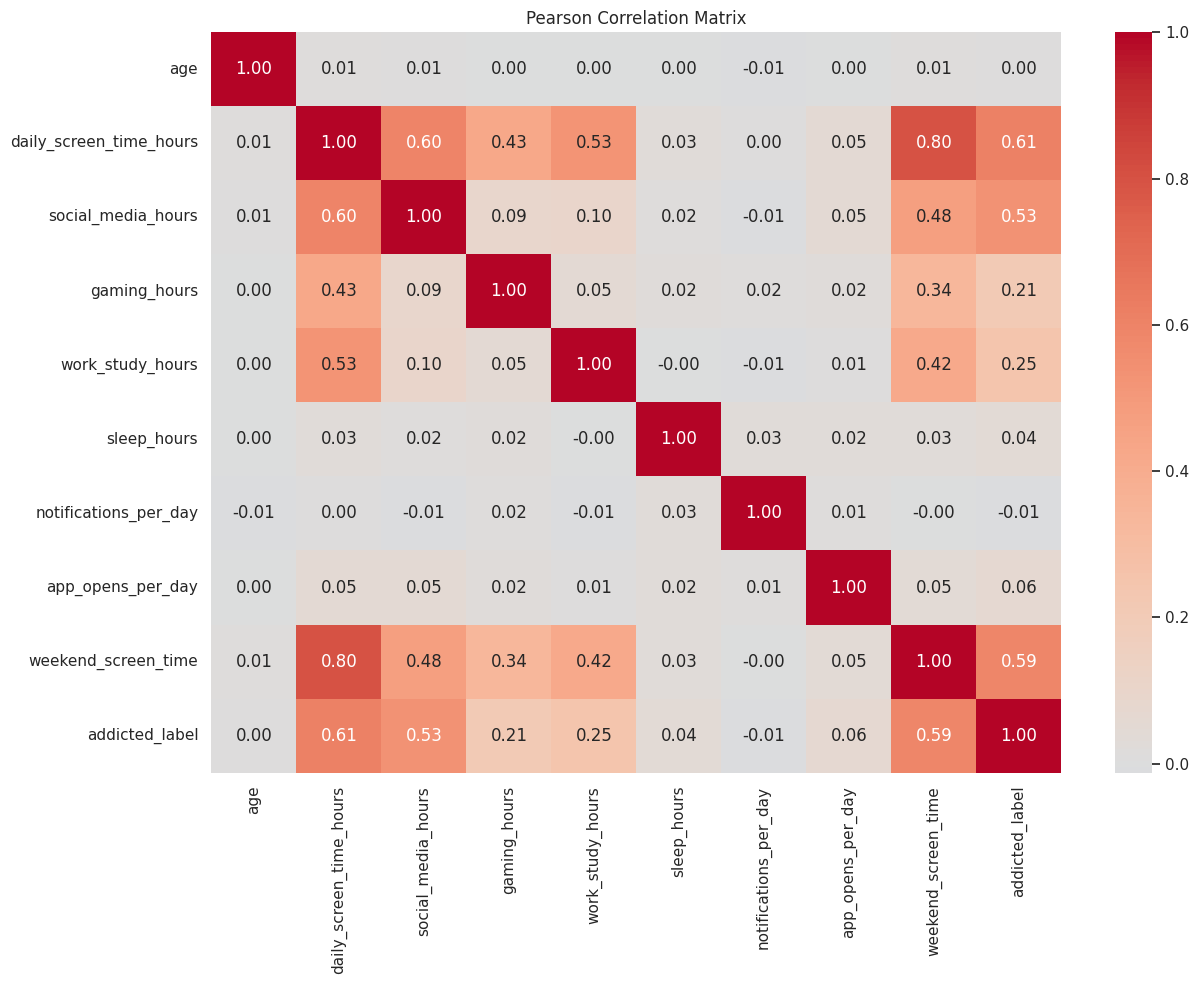

In [26]:
corr = data[
    numeric_features + [target]
].corr(method="pearson")
plt.figure(figsize=(13, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

| المتغيرات المرتبطة | قوة الارتباط (معامل بيرسون) | الاستنتاج المباشر |
| :--- | :--- | :--- |
| **ساعات الشاشة اليومية** (daily_screen_time_hours) و **وقت شاشات نهاية الأسبوع** (weekend_screen_time) | 0.80[cite: 1] | ارتباط قوي جداً يوضح أن الأشخاص الذين يستخدمون الشاشات بكثافة خلال أيام الأسبوع يستمرون بنفس النمط أو أكثر خلال عطلة نهاية الأسبوع[cite: 1]. |
| **ساعات الشاشة اليومية** و **مؤشر الإدمان** (addicted_label) | 0.61[cite: 1] | إجمالي وقت الشاشة اليومي هو المؤشر الأقوى والأكثر ارتباطاً بخطر الإدمان الرقمي[cite: 1]. |
| **وقت شاشات نهاية الأسبوع** و **مؤشر الإدمان** | 0.59[cite: 1] | الاستخدام المكثف للشاشات خلال العطلات يرتبط بشكل ملحوظ بارتفاع احتمالية الإدمان[cite: 1]. |
| **ساعات التواصل الاجتماعي** (social_media_hours) و **مؤشر الإدمان** | 0.53[cite: 1] | وسائل التواصل الاجتماعي لها دور معتبر ومؤثر في زيادة الإدمان، وهو تأثير يفوق الأنشطة الرقمية الأخرى[cite: 1]. |
| **ساعات الألعاب** (gaming_hours) و **مؤشر الإدمان** | 0.21[cite: 1] | ارتباط ضعيف يشير إلى أن ممارسة الألعاب أقل تأثيراً على تصنيف الإدمان في هذه البيانات مقارنة بالتواصل الاجتماعي[cite: 1]. |
| **العمر، ساعات النوم، الإشعارات** مع **مؤشر الإدمان** | من -0.01 إلى 0.04[cite: 1] | عوامل مثل العمر (0.00)، عدد ساعات النوم (0.04)، ومعدل الإشعارات (-0.01) لا تمتلك أي ارتباط حقيقي أو تأثير يُذكر على مؤشر إدمان الشاشات بناءً على ملف "image_39fe90.png"[cite: 1]. |

In [27]:
target_corr = (
    corr[target]
    .drop(target)
    .sort_values( ascending=False)
)
display(target_corr)

,addicted_label
daily_screen_time_hours,0.611398
weekend_screen_time,0.589903
social_media_hours,0.532409
work_study_hours,0.251416
gaming_hours,0.205283
app_opens_per_day,0.063482
sleep_hours,0.042545
age,0.004043
notifications_per_day,-0.011583


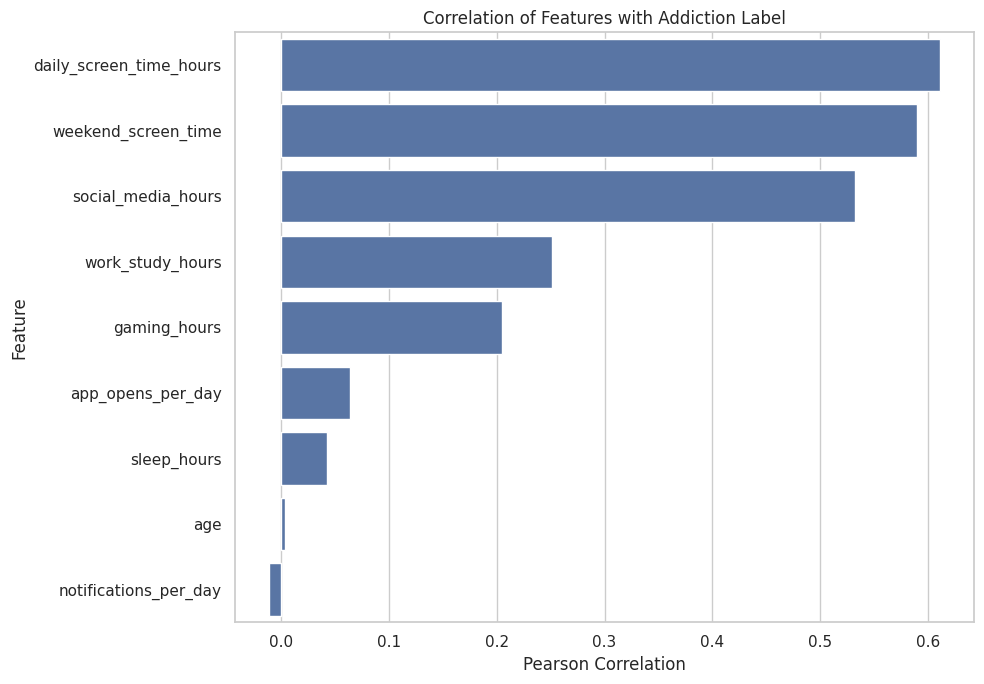

In [28]:
plt.figure(figsize=(10, 7))
sns.barplot(
    x=target_corr.values,
    y=target_corr.index
)
plt.title("Correlation of Features with Addiction Label")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#  PEARSON vs SPEARMAN

In [29]:
pearson = data[
    numeric_features + [target]
].corr(method="pearson")[target].drop(target)

spearman = data[
    numeric_features + [target]
].corr(method="spearman")[target].drop(target)

correlation_comparison = pd.DataFrame({
    "Pearson": pearson,
    "Spearman": spearman
})
correlation_comparison["Difference"] = (
    correlation_comparison["Spearman"] -
    correlation_comparison["Pearson"]
)

display(
    correlation_comparison.sort_values(
        "Spearman",
        ascending=False
    )
)

,Pearson,Spearman,Difference
daily_screen_time_hours,0.611398,0.612873,0.001476
weekend_screen_time,0.589903,0.599363,0.009461
social_media_hours,0.532409,0.562720,0.030311
work_study_hours,0.251416,0.243620,-0.007796
gaming_hours,0.205283,0.191866,-0.013417
app_opens_per_day,0.063482,0.064332,0.000850
sleep_hours,0.042545,0.042404,-0.000141
age,0.004043,0.003579,-0.000464
notifications_per_day,-0.011583,-0.012357,-0.000773


| المحور / المتغيرات | الملاحظة الإحصائية (مقارنة بيرسون وسبيرمان) | الاستنتاج التحليلي |
| :--- | :--- | :--- |
| **إجمالي وقت الشاشة (اليومي ونهاية الأسبوع)** | تطابق شبه تام بين المقياسين (الخطي والترتيبي). | علاقة قوية ومستقرة مع الإدمان الرقمي، وتتصاعد بمعدل ثابت وواضح ويسهل التنبؤ بها. |
| **ساعات التواصل الاجتماعي** | ظهور أكبر فرق بين المقياسين (سبيرمان أعلى من بيرسون). | تأثير هذه الساعات يأخذ نمطاً رتيباً (Monotonic) لا خطياً؛ مما يعني أن أي زيادة ترفع خطر الإدمان باستمرار، حتى وإن لم تكن الزيادة بمعدل رياضي ثابت. |
| **ساعات العمل/الدراسة والألعاب** | ارتباط ضعيف في كلا المقياسين (يتراوح بين 0.19 و 0.25). | الاستخدام الموجه (كالعمل أو اللعب) أقل خطورة في التسبب بالإدمان، فالخطر الأكبر يكمن في الاستهلاك غير الموجه مثل تصفح التواصل الاجتماعي. |
| **الإشعارات، مرات فتح التطبيقات، العمر، وساعات النوم** | معاملات ارتباط شبه صفرية في كلا المقياسين. | هذه العوامل ليس لها أي تأثير يُذكر، ولا تصلح كسمات تنبؤية (Predictive Features) لبناء نماذج الذكاء الاصطناعي لتقييم الإدمان في هذه البيانات. |

In [30]:
sample_size = min(5000, len(data))

sample_data = data.sample(
    sample_size,
    random_state=42
)

# معرفة العلاقات بين المتغيرات

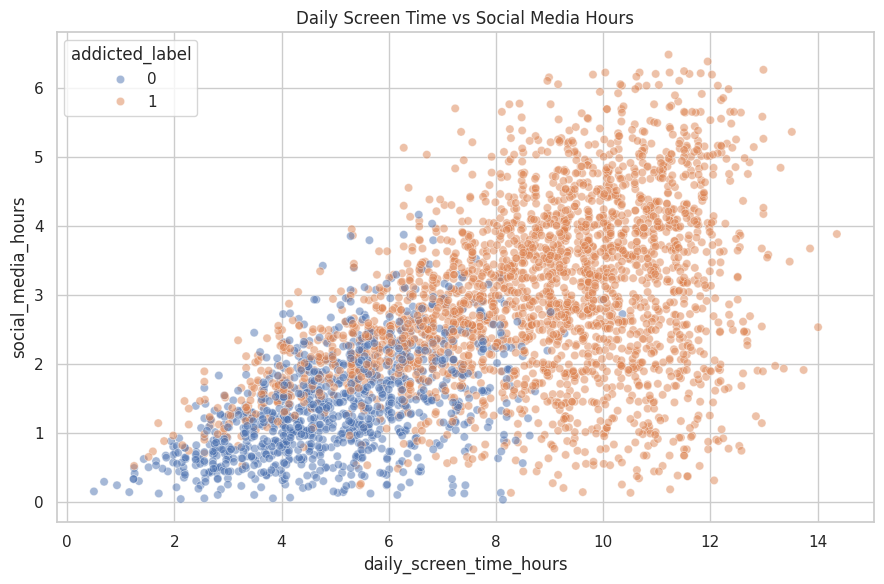

In [31]:
# Scatter Plots مهمة

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=sample_data,
    x="daily_screen_time_hours",
    y="social_media_hours",
    hue="addicted_label",
    alpha=0.5
)

plt.title(
    "Daily Screen Time vs Social Media Hours"
)

plt.tight_layout()
plt.show()

| الملاحظة البيانية من المخطط  | الاستنتاج التحليلي لتصنيف الإدمان |
| :--- | :--- |
| **العلاقة بين وقت الشاشة اليومي واستخدام التواصل الاجتماعي** | علاقة طردية واضحة؛ فزيادة وقت الشاشة العام يقابلها عادة زيادة في وقت التواصل الاجتماعي[cite: 2]. |
| **نمط فئة "غير المدمنين" (النقاط الزرقاء - 0)** | يتركز استخدامهم في النطاق المنخفض، وعادة ما يكون أقل من 8 ساعات كإجمالي وقت الشاشة وأقل من 3 ساعات للتواصل الاجتماعي[cite: 2]. |
| **نمط فئة "المدمنين" (النقاط البرتقالية - 1)** | يظهر تركيزهم بكثافة عندما يتجاوز الاستخدام اليومي 6 ساعات للشاشات وساعتين لوسائل التواصل الاجتماعي[cite: 2]. |
| **التوزيع العام ومنطقة التداخل (Overlap)** | المتغيران يشكلان مؤشرات قوية لفصل الفئتين بوضوح في الحالات المتطرفة، مع وجود منطقة تداخل في الاستخدام المتوسط (4 إلى 8 ساعات) قد تتطلب الاعتماد على متغيرات إضافية لحسم التصنيف بدقة[cite: 2]. |

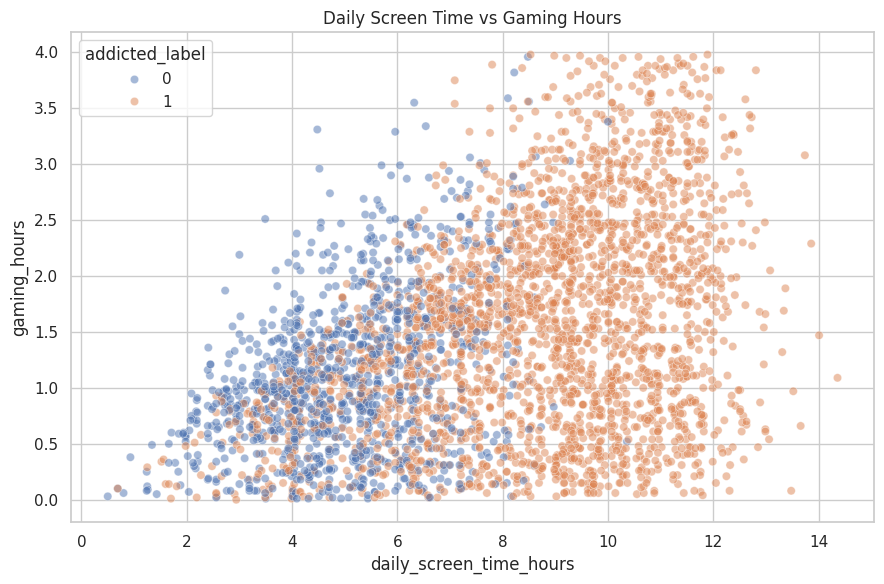

In [32]:
# علاقة Gaming مع Screen Time
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=sample_data,
    x="daily_screen_time_hours",
    y="gaming_hours",
    hue="addicted_label",
    alpha=0.5
)

plt.title(
    "Daily Screen Time vs Gaming Hours"
)

plt.tight_layout()
plt.show()

| الملاحظة البيانية من المخطط ( | الاستنتاج التحليلي لتصنيف الإدمان |
| :--- | :--- |
| **العلاقة بين وقت الشاشة اليومي وساعات الألعاب** | لا يظهر المخطط علاقة طردية واضحة؛ حيث يمتلك العديد من المستخدمين ساعات شاشة إجمالية عالية (أكثر من 10 ساعات) بينما ساعات لعبهم تقترب من الصفر[cite: 3]. |
| **ضعف التمييز عبر ساعات الألعاب (المحور الصادي)** | هذا المتغير ضعيف في فصل الفئتين؛ فالنقاط الزرقاء والبرتقالية تنتشر وتتداخل عبر كامل نطاق ساعات اللعب (من 0 إلى 4 ساعات)[cite: 3]. |
| **قوة إجمالي وقت الشاشة (المحور السيني)** | الفصل بين فئة المدمنين (1) وغير المدمنين (0) يتم بشكل شبه كلي بناءً على المحور الأفقي، حيث تسيطر الفئة البرتقالية بمجرد تجاوز الاستخدام اليومي 6 إلى 8 ساعات، بغض النظر عن المدة المقضية في الألعاب[cite: 3]. |
| **مقارنة التداخل (Overlap)** | التداخل العشوائي والكثيف هنا يؤكد ما أظهره جدول الارتباط السابق: الألعاب ليست المحرك أو المؤشر الأساسي للإدمان في هذه البيانات مقارنة بوسائل التواصل الاجتماعي[cite: 3]. |

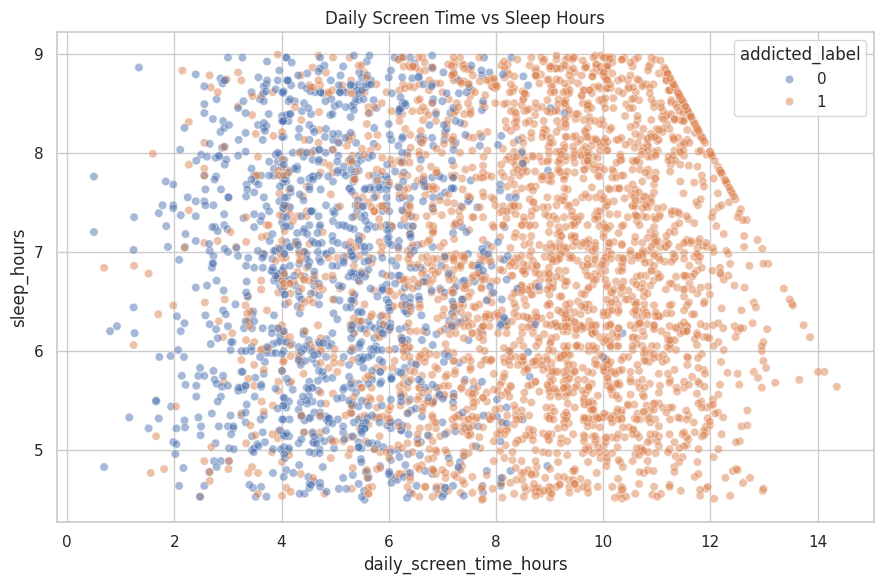

In [33]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=sample_data,
    x="daily_screen_time_hours",
    y="sleep_hours",
    hue="addicted_label",
    alpha=0.5
)

plt.title(
    "Daily Screen Time vs Sleep Hours"
)

plt.tight_layout()
plt.show()

| الملاحظة البيانية من المخطط | الاستنتاج التحليلي لتصنيف الإدمان |
| :--- | :--- |
| **العلاقة بين وقت الشاشة وساعات النوم** | لا يوجد أي ارتباط طردي أو عكسي بين المتغيرين؛ فالنقاط مبعثرة بشكل واسع، مما يعني أن زيادة أو نقصان وقت الشاشة لا يرتبط بنمط نوم محدد في هذه البيانات[cite: 4]. |
| **انعدام القدرة التمييزية لساعات النوم (المحور الصادي)** | ساعات النوم متداخلة تماماً ولا تلعب أي دور في فصل الفئتين؛ حيث تتوزع النقاط الزرقاء (0) والبرتقالية (1) بكثافة متساوية تقريباً عبر جميع معدلات النوم (من 4.5 إلى 9 ساعات)[cite: 4]. |
| **السيطرة التامة لوقت الشاشة (المحور السيني)** | التمييز بين فئة "غير المدمنين" و"المدمنين" يحدث بشكل أفقي بحت؛ فالتصنيف يعتمد كلياً على المحور السيني (وقت الشاشة)، حيث تظهر فئة المدمنين بوضوح بمجرد تجاوز عتبة الـ 6-8 ساعات شاشة، مهما كانت عدد ساعات نومهم[cite: 4]. |
| **الحد الأقصى للبيانات (القطع القُطري العلوي الأيمن)** | يظهر قطع قُطري حاد في الزاوية العلوية اليمنى للمخطط، مما يشير إلى وجود قيد رياضي أو طبيعي في البيانات يمنع تجاوز مجموع ساعات النوم والشاشة معاً لحاجز زمني معين خلال اليوم الواحد[cite: 4]. |

# تحليل المتغيرات الفئوية مع الهدف

In [34]:
for col in categorical_features:
    crosstab = pd.crosstab(
        data[col],
        data[target],
        normalize="index"
    ) * 100
    print(col)
    print("=" * 70)

    display(crosstab)

gender


addicted_label,0,1
gender,,
Female,29.616192,70.383808
Male,27.680160,72.319840
Other,29.898009,70.101991


stress_level


addicted_label,0,1
stress_level,,
High,28.856854,71.143146
Low,28.883980,71.116020
Medium,29.433671,70.566329


academic_work_impact


addicted_label,0,1
academic_work_impact,,
No,28.897053,71.102947
Yes,29.211716,70.788284


# رسم نسبة الإدمان داخل كل فئة

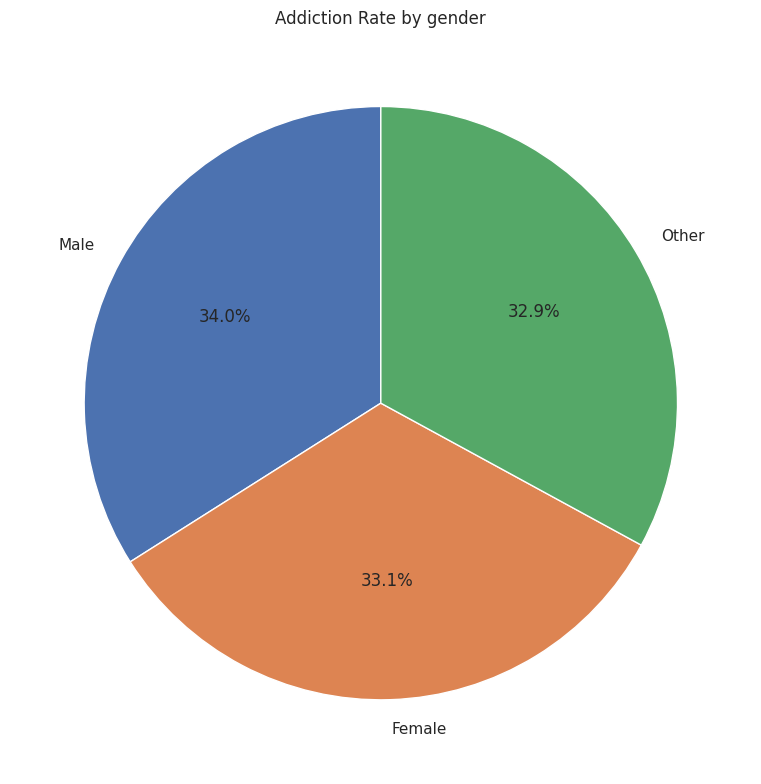

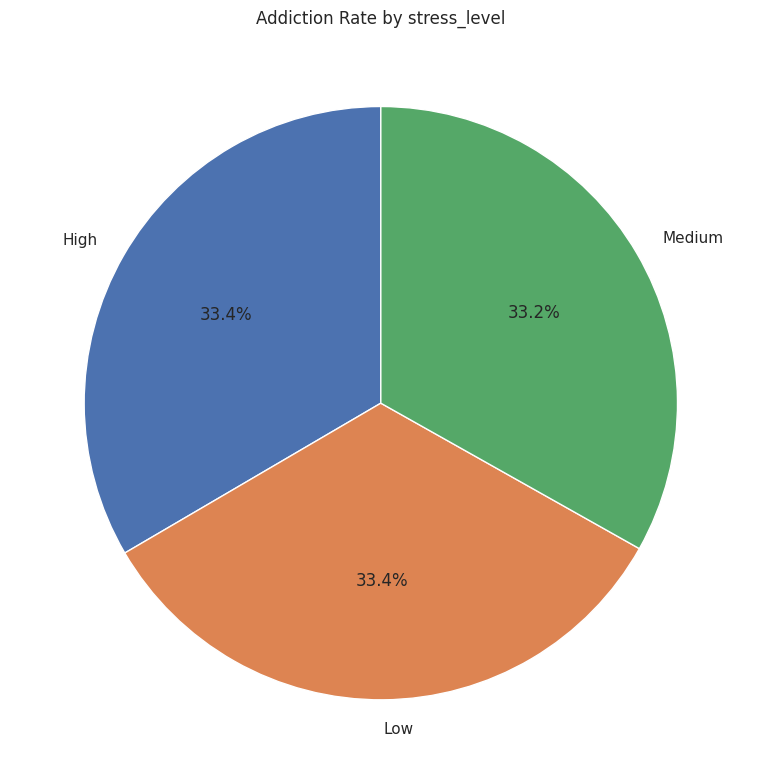

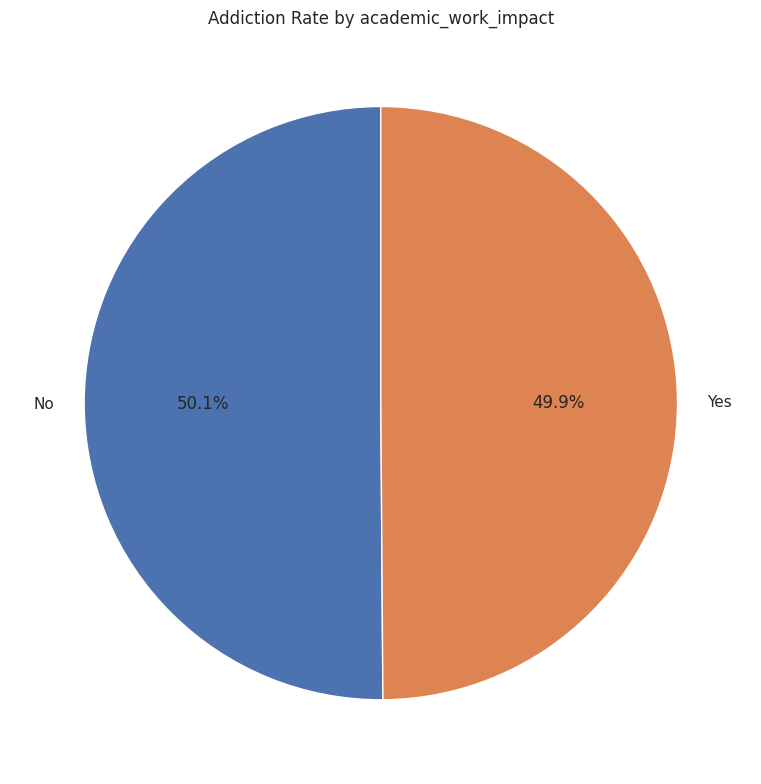

In [35]:
for col in categorical_features:

    addiction_rate = (
        data.groupby(col)[target]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    plt.figure(figsize=(8, 8))

    plt.pie(
        addiction_rate.values,
        labels=addiction_rate.index,
        autopct="%.1f%%",
        startangle=90
    )

    plt.title(
        f"Addiction Rate by {col}"
    )

    plt.tight_layout()
    plt.show()

#  العمر مع الإدمان

In [36]:
data["age_group"] = pd.cut(
    data["age"],
    bins=[17, 20, 25, 30, 35],
    labels=[
        "18-20",
        "21-25",
        "26-30",
        "31-35"
    ]
)
age_addiction = ( # نحسب معدل الادمان
    data.groupby("age_group", observed=True)[target]
    .mean()
    * 100
)
display(age_addiction)

,addicted_label
age_group,
18-20,68.992697
21-25,70.940878
26-30,72.746775
31-35,70.233599


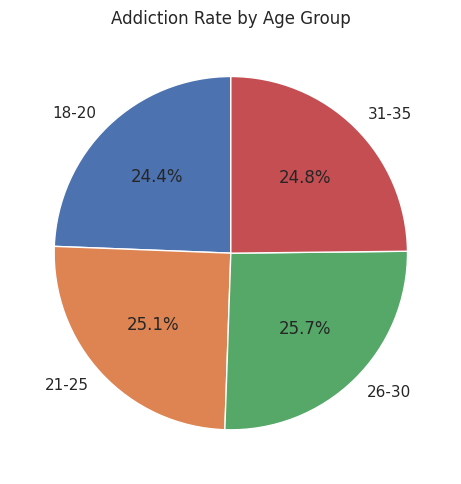

In [37]:
plt.figure(figsize=(9, 5))

plt.pie(
    age_addiction.values,
    labels=age_addiction.index,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Addiction Rate by Age Group")

plt.tight_layout()
plt.show()

In [38]:
# تحليل Screen Time على شكل فئات
# ============================================================
# 29. SCREEN TIME GROUPS
# ============================================================

data["screen_time_group"] = pd.cut(
    data["daily_screen_time_hours"],
    bins=[0, 4, 6, 8, 10, 12, 16],
    labels=[
        "<4",
        "4-6",
        "6-8",
        "8-10",
        "10-12",
        "12+"
    ]
)

screen_addiction = (
    data.groupby(
        "screen_time_group",
        observed=True
    )[target]
    .mean() * 100
)

display(screen_addiction)

,addicted_label
screen_time_group,
<4,26.544713
4-6,35.576509
6-8,66.522717
8-10,95.476883
10-12,99.868997
12+,99.967159


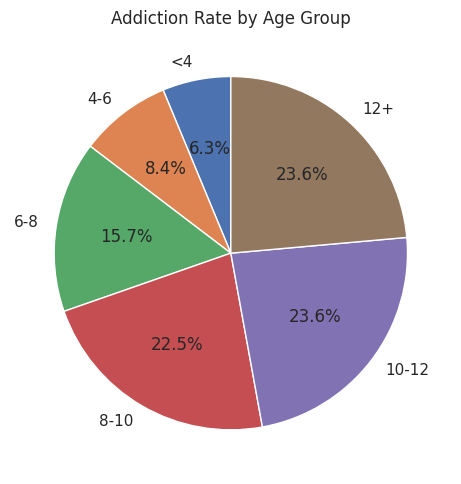

In [39]:
plt.figure(figsize=(9, 5))

plt.pie(
    screen_addiction.values,
    labels=screen_addiction.index,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Addiction Rate by Age Group")

plt.tight_layout()
plt.show()

# القلاقه بين الادمان و معدل الظغط النفسي

In [40]:

stress_addiction = (
    data.groupby("stress_level")[target]
    .mean()
    .sort_values()
    * 100
)

display(stress_addiction)

,addicted_label
stress_level,
Medium,70.566329
Low,71.116020
High,71.143146


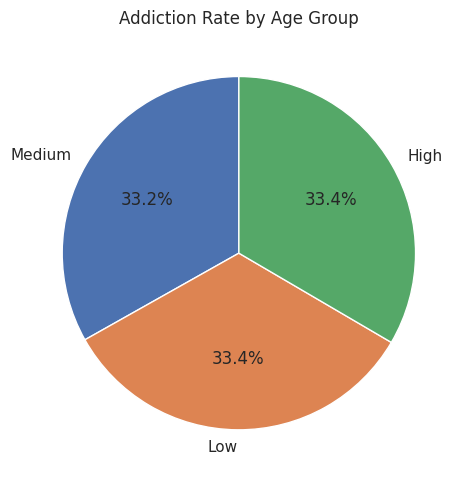

In [41]:
plt.figure(figsize=(9, 5))

plt.pie(
    stress_addiction.values,
    labels=stress_addiction.index,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Addiction Rate by Age Group")

plt.tight_layout()
plt.show()

# العلاقه بين استخدام الهاتف على العمل  مع الادمان

In [42]:
# Academic Work Impact × Addiction
academic_addiction = (
    data.groupby("academic_work_impact")[target]
    .mean()
    .sort_values()
    * 100
)

display(academic_addiction)

,addicted_label
academic_work_impact,
Yes,70.788284
No,71.102947


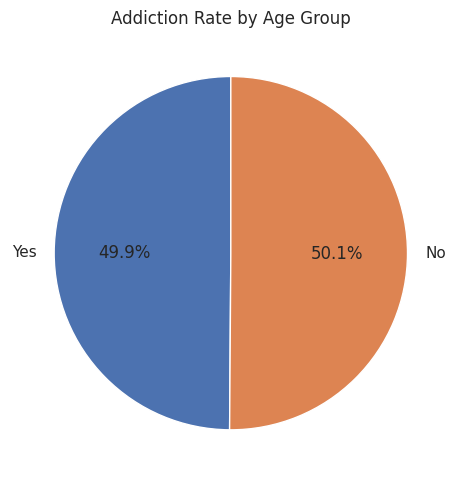

In [43]:
plt.figure(figsize=(9, 5))

plt.pie(
    academic_addiction.values,
    labels=academic_addiction.index,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Addiction Rate by Age Group")

plt.tight_layout()
plt.show()

# معرفة أي المتغيرات تحتوي على معلومات أكثر ارتباطًا بالمتغير المستهدف

In [70]:
mi_data = data.copy()
for col in categorical_features:
    mi_data[col] = (
        mi_data[col]
        .astype("category")
        .cat.codes
    )

mi_features = numeric_features + categorical_features

X_mi = mi_data[mi_features].copy()
y_mi = mi_data[target]
X_mi = X_mi.fillna(X_mi.median(numeric_only=True))
mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": mi_features,
    "Mutual_Information": mi_scores
})

mi_df = mi_df.sort_values(
    "Mutual_Information",
    ascending=False
)

display(mi_df)

,Feature,Mutual_Information
1,daily_screen_time_hours,0.224151
8,weekend_screen_time,0.206801
2,social_media_hours,0.161063
6,notifications_per_day,0.086768
7,app_opens_per_day,0.078726
4,work_study_hours,0.040917
9,gender,0.037515
10,stress_level,0.036211
11,academic_work_impact,0.030908
3,gaming_hours,0.030404


| تصنيف المتغيرات (حسب الأهمية التنبؤية) | المتغيرات | مجموع الأهمية التقريبي | الاستنتاج التحليلي (Feature Importance Analysis) |
| :--- | :--- | :--- | :--- |
| **المحددات الأساسية (السمات الجوهرية)** | إجمالي ساعات الشاشة، وقت نهاية الأسبوع، ساعات التواصل الاجتماعي | ~ 59.2% | هذه المتغيرات الثلاثة هي المحرك الأساسي لنموذج التصنيف وتستحوذ على النصيب الأكبر من القدرة التنبؤية؛ مما يؤكد أن مدة الاستخدام الكلية والنشاط الاجتماعي هما المقياس الحقيقي لتقييم الإدمان. |
| **المؤشرات السلوكية الثانوية** | الإشعارات اليومية، مرات فتح التطبيقات | ~ 16.5% | رغم ضعف ارتباطها الخطي في التحليلات السابقة، تظهر هنا كسمات ذات تأثير متوسط، مما يعني أن خوارزمية التصنيف تلتقط تفاعلات لا خطية تعكس "السلوك النمطي المتكرر" (Habitual Checking) كمؤشر مساعد. |
| **الأنشطة الموجهة والعوامل النفسية** | ساعات العمل/الدراسة، مستوى التوتر، التأثير الأكاديمي، ساعات الألعاب | ~ 13.8% | تأثيرها ضعيف ومحدود. الاستخدام الموجه (كالعمل والألعاب) أو الحالة النفسية (التوتر) تلعب دوراً هامشياً جداً في بناء قرار النموذج مقارنة بالتصفح العام. |
| **السمات الديموغرافية والبيولوجية (المرشحة للاستبعاد)** | الجنس، ساعات النوم، العمر | ~ 5.9% | تمتلك أدنى درجات الأهمية (Information Gain/Gini Impurity منخفض جداً). في سياق تنقيح البيانات (Feature Selection)، يمكن استبعاد هذه المتغيرات لتبسيط النموذج دون فقدان دقة التصنيف. |

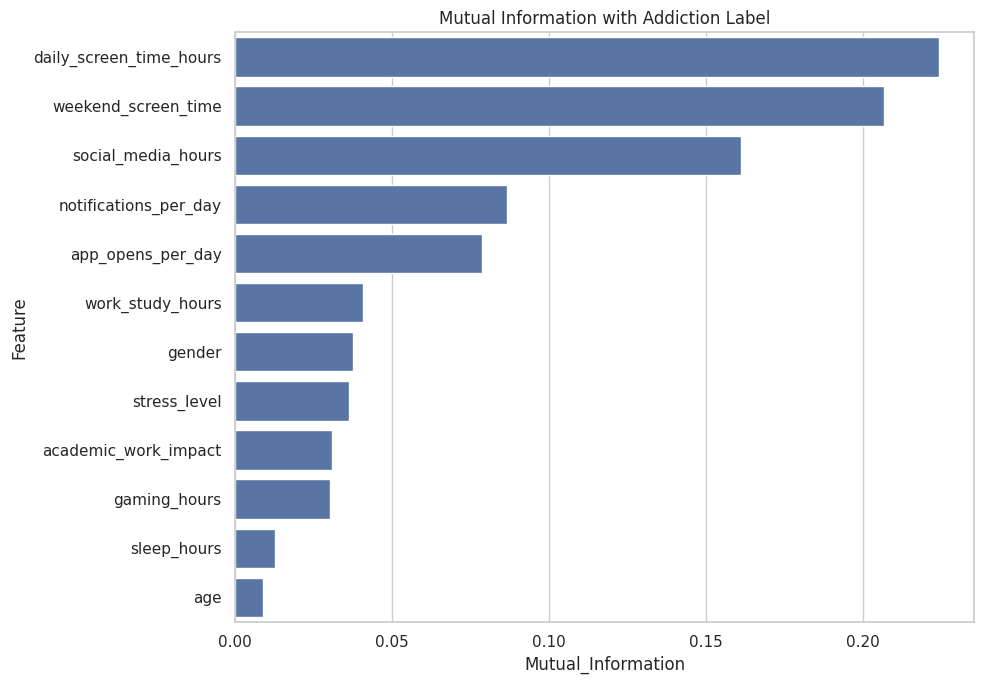

In [71]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=mi_df,
    x="Mutual_Information",
    y="Feature"
)

plt.title(
    "Mutual Information with Addiction Label"
)

plt.tight_layout()
plt.show()

# معرفه المعلومات المتشابهه بين المتغيرات

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = data[numeric_features].copy()
vif_data = vif_data.fillna(
    vif_data.median()
)
vif_results = pd.DataFrame()
vif_results["Feature"] = vif_data.columns
vif_results["VIF"] = [
    variance_inflation_factor(
        vif_data.values,
        i
    )
    for i in range(vif_data.shape[1])
]
display(
    vif_results.sort_values(
        "VIF",
        ascending=False
    )
)

,Feature,VIF
1,daily_screen_time_hours,2.947760
8,weekend_screen_time,2.021397
2,social_media_hours,1.495844
4,work_study_hours,1.409504
3,gaming_hours,1.246250
7,app_opens_per_day,1.003402
5,sleep_hours,1.002006
6,notifications_per_day,1.001406
0,age,1.000246


# Data preprocessing

In [50]:
import numpy as np
import pandas as pd

target = "addicted_label"

numerical_features = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

categorical_features = [
    "gender",
    "stress_level",
    "academic_work_impact"
]
X = data[numerical_features + categorical_features].copy()
y = data[target].copy()

for col in categorical_features:
    X[col] = X[col].astype(str).str.strip()
    X[col] = X[col].replace({
        "": np.nan,
        "nan": np.nan,
        "None": np.nan
    })
print("X shape:", X.shape)
print("\nColumns:")
print(X.columns.tolist())

X shape: (691369, 12)

Columns:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']


In [51]:

X.isnull().sum()

,0
age,28929
daily_screen_time_hours,95854
social_media_hours,133995
gaming_hours,126821
work_study_hours,51518
sleep_hours,44480
notifications_per_day,67584
app_opens_per_day,80710
weekend_screen_time,112063
gender,29034


In [52]:


numeric_columns = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

categorical_columns = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

# الأعمدة الرقمية
for column in numeric_columns:
    X[column] = pd.to_numeric(X[column], errors="coerce")
    X[column] = X[column].fillna(X[column].median())

# الأعمدة النصية
for column in categorical_columns:
    X[column] = X[column].fillna(X[column].mode()[0])

In [53]:
X.isnull().sum()

,0
age,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0
app_opens_per_day,0
weekend_screen_time,0
gender,0


In [54]:
numeric_cols = X.select_dtypes(include=[np.number]).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())
for col in numeric_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X[col] = X[col].clip(lower=lower_bound, upper=upper_bound)

In [55]:
# تحديد الأعمدة العددية فقط
numeric_cols = X.select_dtypes(include=[np.number]).columns
outliers_count = {}
for col in numeric_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    count = ((X[col] < lower_bound) | (X[col] > upper_bound)).sum()
    outliers_count[col] = count
outliers_series = pd.Series(outliers_count)
total_outliers = outliers_series.sum()

if total_outliers == 0:
    print("ممتاز! لا توجد أي قيم متطرفة متبقية في البيانات.")
else:
    print(f"تنبيه: لا يزال هناك {total_outliers} قيمة متطرفة في البيانات.")
    print("\nتفاصيل القيم المتطرفة في كل عمود:")
    # طباعة الأعمدة التي تحتوي على قيم متطرفة فقط
    print(outliers_series[outliers_series > 0])

ممتاز! لا توجد أي قيم متطرفة متبقية في البيانات.


In [56]:
X.duplicated().sum()

np.int64(0)

In [57]:
target_counts = data[target].value_counts()
print(target_counts)
print("\nPercentages:")
print(
    data[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# يوجد تحيز في البيانات

addicted_label
1    490474
0    200895
Name: count, dtype: int64

Percentages:
addicted_label
1    70.94
0    29.06
Name: proportion, dtype: float64


# موازنه الفئات

In [58]:
from imblearn.over_sampling import RandomOverSampler
X =X
y = y
ros = RandomOverSampler(random_state=42)
X, y = ros.fit_resample(X, y)
print(y.value_counts())

addicted_label
1    490474
0    490474
Name: count, dtype: int64


In [59]:
X

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,24.0,7.77,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No
1,19.0,5.97,1.08,1.33,3.03,8.22,76.0,19.0,9.58,Female,Medium,No
2,18.0,5.09,2.31,1.33,2.20,6.25,134.0,60.0,7.47,Female,Low,Yes
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,Yes
4,26.0,11.20,1.87,2.81,1.95,5.25,150.0,104.0,13.39,Female,Medium,No
...,...,...,...,...,...,...,...,...,...,...,...,...
980943,20.0,7.77,2.31,1.33,0.88,5.68,121.0,104.0,6.02,Female,Medium,Yes
980944,35.0,4.80,0.53,1.33,3.29,8.50,58.0,134.0,3.61,Other,Low,No
980945,25.0,7.77,2.31,0.81,1.53,8.88,150.0,115.0,7.56,Female,High,No
980946,19.0,5.11,0.50,1.33,1.91,8.60,150.0,104.0,9.58,Other,Medium,No


In [60]:

print(X.dtypes)

age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                      object
stress_level                object
academic_work_impact        object
dtype: object


In [62]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
categorical_columns = [
    "gender",
    "stress_level",
    "academic_work_impact"
]
for column in categorical_columns:
    X[column] = encoder.fit_transform(X[column].astype(str))

In [63]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [64]:
X

array([[-0.51629995,  0.30374474, -0.30388444, ...,  0.00735823,
         1.32056025, -1.09015764],
       [-1.50124333, -0.40395931, -0.96831761, ..., -1.24316842,
         1.32056025, -1.09015764],
       [-1.69823201, -0.74994796,  0.12135279, ..., -1.24316842,
         0.11703409,  0.91729853],
       ...,
       [-0.31931127,  0.30374474,  0.12135279, ..., -1.24316842,
        -1.08649206, -1.09015764],
       [-1.50124333, -0.74208458, -1.48214593, ...,  1.25788488,
         1.32056025, -1.09015764],
       [ 0.86262079, -1.56380762, -0.90630385, ...,  0.00735823,
         1.32056025,  0.91729853]])

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (784758, 12)
X_valid: (196190, 12)
y_train: (784758,)
y_valid: (196190,)


In [66]:
import time
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ),

    "HistGradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)




# تقييم النماذج

In [67]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score,
    confusion_matrix
)

evaluation_results = []
predictions = {}
probabilities = {}
confusion_matrices = {}

for name, model in models.items():
    y_pred = model.predict(X_valid)
    y_prob = model.predict_proba(X_valid)[:, 1]
    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred, zero_division=0),
        "Recall": recall_score(y_valid, y_pred, zero_division=0),
        "F1": f1_score(y_valid, y_pred, zero_division=0)
    })

    predictions[name] = y_pred
    probabilities[name] = y_prob
    confusion_matrices[name] = confusion_matrix(y_valid, y_pred)

evaluation_df = pd.DataFrame(evaluation_results)

display(
    evaluation_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
    })
)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8373,0.8429,0.8292,0.8360
1,Decision Tree,0.8571,0.8997,0.8039,0.8491
2,Random Forest,0.8616,0.9149,0.7973,0.8521
3,HistGradient Boosting,0.8871,0.9146,0.8540,0.8832
4,KNN,0.8514,0.8998,0.7909,0.8419


# مقارنه النتائج

In [72]:
comparison_df = evaluation_df.copy()


display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

for metric in metrics:
    row = comparison_df.loc[comparison_df[metric].idxmax()]
    print(f"{metric:12s} → {row['Model']:25s} = {row[metric]:.4f}")

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8373,0.8429,0.8292,0.8360
1,Decision Tree,0.8571,0.8997,0.8039,0.8491
2,Random Forest,0.8616,0.9149,0.7973,0.8521
3,HistGradient Boosting,0.8871,0.9146,0.8540,0.8832
4,KNN,0.8514,0.8998,0.7909,0.8419


Accuracy     → HistGradient Boosting     = 0.8871
Precision    → Random Forest             = 0.9149
Recall       → HistGradient Boosting     = 0.8540
F1           → HistGradient Boosting     = 0.8832


# عرض التقييم بصريا

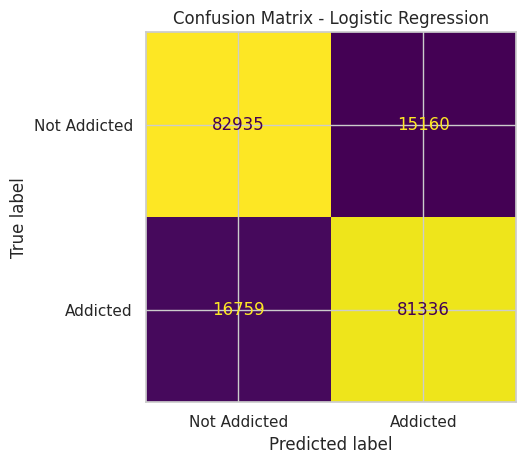

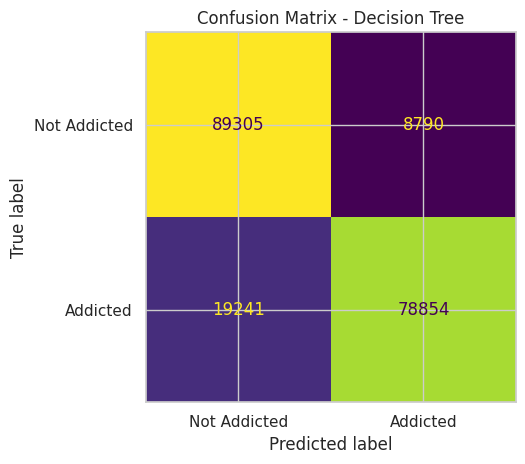

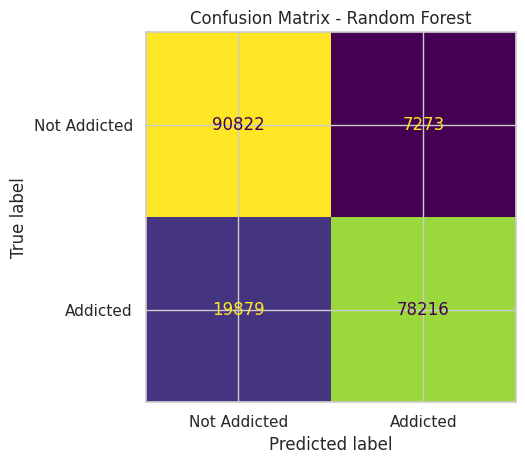

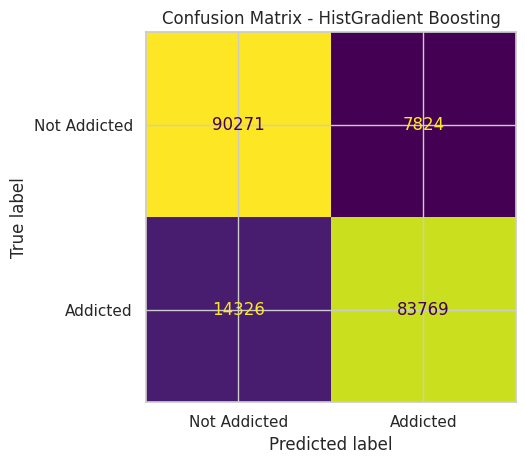

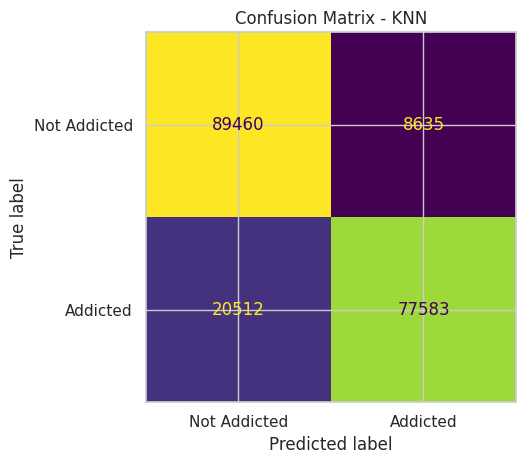

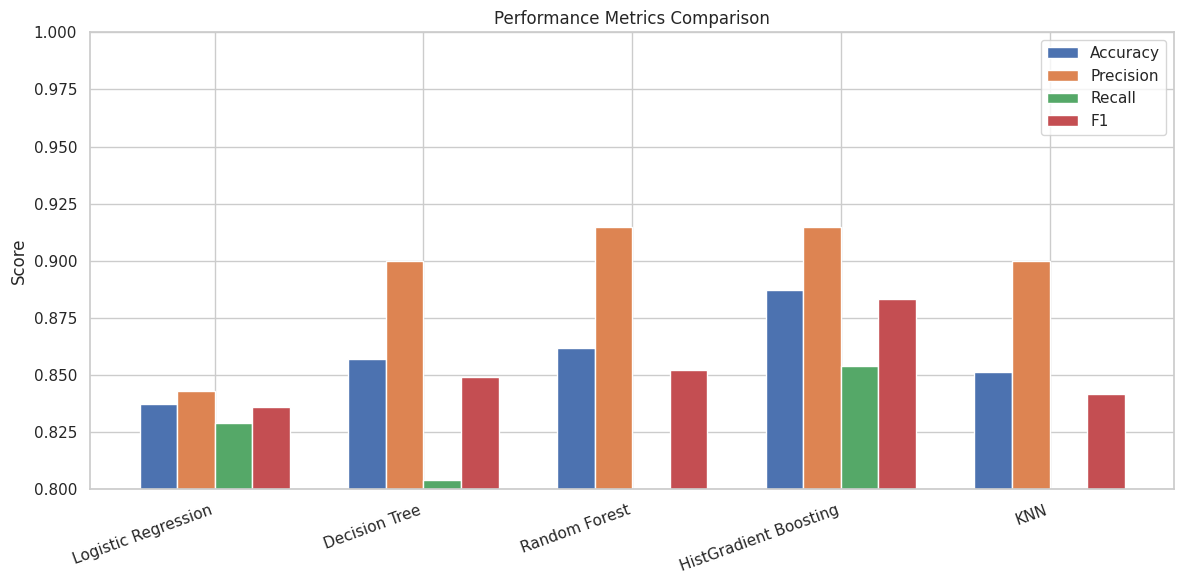

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrices
for name, cm in confusion_matrices.items():

    ConfusionMatrixDisplay(
        cm,
        display_labels=["Not Addicted", "Addicted"]
    ).plot(values_format="d", colorbar=False)

    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()


# Metrics Comparison
metrics = ["Accuracy", "Precision", "Recall", "F1"]
models = evaluation_df["Model"]
x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        evaluation_df[metric],
        width,
        label=metric
    )

plt.xticks(x, models, rotation=20, ha="right")
plt.ylabel("Score")
plt.title("Performance Metrics Comparison")
plt.ylim(0.80, 1.00)
plt.legend()
plt.tight_layout()
plt.show()

# اختبار النمماذج على بيانات اخرى

In [75]:
import pandas as pd
import numpy as np
test_path = "/content/drive/MyDrive/test.csv"
test = pd.read_csv(test_path)

print("=" * 80)
print("TEST DATA")
print("=" * 80)
print("Shape:", test.shape)
display(test.head())
print("\nColumns:")
print(test.columns.tolist())

TEST DATA
Shape: (296302, 13)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No



Columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']


In [76]:
test.isnull().sum()

,0
id,0
age,17138
daily_screen_time_hours,32788
social_media_hours,47397
gaming_hours,59420
work_study_hours,27777
sleep_hours,22455
notifications_per_day,34221
app_opens_per_day,25705
weekend_screen_time,50697


In [77]:
test_features = numerical_features + categorical_features



In [78]:
test_features

['age',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'gender',
 'stress_level',
 'academic_work_impact']

In [79]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
test = pd.read_csv(test_path)
test = test.drop_duplicates().reset_index(drop=True)
numerical_features = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]
for col in numerical_features:
    test[col] = pd.to_numeric(
        test[col],
        errors="coerce"
    )
    test[col] = test[col].fillna(
        test[col].median()
    )



In [80]:
test.isnull().sum()

,0
id,0
age,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0
app_opens_per_day,0
weekend_screen_time,0


In [81]:
from sklearn.preprocessing import OrdinalEncoder
for col in categorical_features:
    test[col] = test[col].fillna(
        test[col].mode()[0]
    )

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

encoder.fit(test[categorical_features])

test[categorical_features] = encoder.transform(
    test[categorical_features]
)

In [82]:
test.isnull().sum()

,0
id,0
age,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0
app_opens_per_day,0
weekend_screen_time,0


In [92]:
# ==========================================
# PREDICTION ON KAGGLE TEST DATA
# ==========================================

X_test = test.copy()

test_predictions = {}
test_probabilities = {}

for name, model in trained_models.items():

    # التنبؤ بالفئة
    y_pred = model.predict(X_test)

    # احتمال الفئة 1
    y_prob = model.predict_proba(X_test)[:, 1]

    test_predictions[name] = y_pred
    test_probabilities[name] = y_prob

print("Test prediction completed successfully.")

for name in test_predictions:
    print(
        f"{name:<30} "
        f"Predictions: {test_predictions[name].shape} | "
        f"Probabilities: {test_probabilities[name].shape}"
    )

NameError: name 'trained_models' is not defined